# Customer Trends & Diagnostics EDA

This notebook is split from `02_customer_behavior.ipynb` for maintainability.


In [2]:
import importlib
import sys
import os
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

In [3]:
DATA_PATH = '../../data/processed/quality'

# Load using Polars (faster, lazy evaluation)
orders = pl.scan_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior = pl.scan_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train = pl.scan_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products = pl.scan_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles = pl.scan_csv(Path(DATA_PATH) / 'aisles_clean.csv')
departments = pl.scan_csv(Path(DATA_PATH) / 'departments_clean.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments,
}

In [4]:
# 0. Load order dates (with date parsing)
order_dates_df = pl.scan_csv('../../data/processed/features/orders_with_dates.csv').select([
    pl.col('order_id'),
    pl.col('order_date').str.strptime(pl.Date, format="%Y-%m-%d")
])

# 1. Build the main query chain (Polars optimizes before execution)
df = (
    tables['orders']
    .join(tables['order_products_prior'], on='order_id', how='left')
    .join(order_dates_df, on='order_id', how='left')
    .join(tables['products'].select(['product_id', 'aisle_id', 'department_id']), 
          on='product_id', how='left')
    .join(tables['aisles'].select(['aisle_id', 'aisle']), 
          on='aisle_id', how='left')
    .join(tables['departments'].select(['department_id', 'department']), 
          on='department_id', how='left')
    .drop(['aisle_id', 'department_id'])
    .with_columns([
        pl.col('order_date').dt.truncate('1mo').alias('order_month')
    ])
    .collect()  # Execute the query
)

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Data loaded: 32,640,698 rows × 14 columns


In [5]:
# Category-level value weight (relative, not actual price)
value_weight_map = {
    # 🟢 Fresh / Low value
    "fresh fruits": 1.0,
    "fresh vegetables": 1.0,
    "packaged vegetables fruits": 1.2,
    "fresh herbs": 1.3,
    "water seltzer sparkling water": 1.1,

    # 🟡 Dairy / Basic food
    "milk": 1.4,
    "yogurt": 1.5,
    "eggs": 1.5,
    "cream": 1.6,
    "butter": 1.6,
    "packaged cheese": 1.7,
    "other creams cheeses": 1.8,

    # 🟡 Bakery / carbs
    "bread": 1.4,
    "buns rolls": 1.4,
    "breakfast bakery": 1.5,
    "tortillas flat bread": 1.5,
    "dry pasta": 1.3,
    "grains rice dried goods": 1.3,

    # 🟡 Snacks / packaged
    "chips pretzels": 1.6,
    "crackers": 1.5,
    "cookies cakes": 1.7,
    "candy chocolate": 1.6,
    "popcorn jerky": 1.7,
    "trail mix snack mix": 1.8,
    "nuts seeds dried fruit": 1.8,

    # 🟡 Drinks
    "soft drinks": 1.4,
    "juice nectars": 1.5,
    "tea": 1.4,
    "coffee": 1.6,
    "energy sports drinks": 1.7,

    # 🔴 Protein / meat
    "meat counter": 2.5,
    "poultry counter": 2.4,
    "seafood counter": 2.7,
    "packaged meat": 2.3,
    "packaged poultry": 2.2,
    "packaged seafood": 2.4,
    "hot dogs bacon sausage": 2.2,
    "lunch meat": 2.0,

    # 🔴 Frozen / prepared
    "frozen meals": 2.0,
    "frozen produce": 1.6,
    "frozen pizza": 2.1,
    "frozen appetizers sides": 2.0,
    "frozen breakfast": 1.8,
    "prepared meals": 2.2,
    "prepared soups salads": 2.0,

    # 🔴 Pantry / cooking
    "canned meals beans": 1.6,
    "canned jarred vegetables": 1.4,
    "canned fruit applesauce": 1.4,
    "pasta sauce": 1.5,
    "condiments": 1.5,
    "spices seasonings": 1.6,
    "oils vinegars": 1.8,
    "baking ingredients": 1.5,
    "doughs gelatins bake mixes": 1.5,

    # 🔴 Special food
    "baby food formula": 2.5,
    "tofu meat alternatives": 2.2,
    "protein meal replacements": 2.6,
    "international": 1.7,
    "asian foods": 1.7,
    "latino foods": 1.6,
    "indian foods": 1.7,

    # 🟣 Premium / alcohol
    "beers coolers": 3.0,
    "red wines": 3.2,
    "white wines": 3.2,
    "spirits": 3.5,
    "specialty wines champagnes": 3.8,

    # 🟣 Non-food high value
    "cleaning products": 2.3,
    "laundry": 2.4,
    "dish detergents": 2.2,
    "paper goods": 2.0,
    "trash bags liners": 2.1,
    "air fresheners candles": 2.2,

    # 🟣 Personal care
    "personal care": 2.5,
    "oral hygiene": 2.3,
    "body lotions soap": 2.4,
    "hair care": 2.4,
    "skin care": 2.6,
    "facial care": 2.6,
    "deodorants": 2.2,
    "feminine care": 2.4,

    # 🟣 Baby / pets
    "diapers wipes": 2.8,
    "baby bath body care": 2.6,
    "baby accessories": 2.7,
    "cat food care": 2.4,
    "dog food care": 2.4,

    # fallback
    "missing": 1.5,
    "other": 1.5
}

# 2) CREATE VALUE INDEX using Polars
# Create mapping expression for Polars
aisle_when_then = pl.lit(1.5)  # default
for aisle_name, weight in value_weight_map.items():
    aisle_when_then = pl.when(pl.col("aisle") == aisle_name).then(pl.lit(weight)).otherwise(aisle_when_then)

df = df.with_columns([
    aisle_when_then.alias("value_weight"),
    (pl.lit(1) * aisle_when_then).alias("value_index"),
    (pl.lit(1) * aisle_when_then).alias("total_price")
])

## RFM Segments (Reorder time)

# 1) Customer Segmentation Value Analysis

แบ่งลูกค้าออกเป็นกลุ่มตามพฤติกรรม แล้วประมาณ **มูลค่าสัมพัทธ์** ของแต่ละกลุ่มผ่าน Value Index

| ขั้นตอน | รายละเอียด |
|---------|-----------|
| 1.1 | สร้าง User Segment (Whales / Regulars / Churned) |
| 1.2 | กำหนด Value Weight ตาม Aisle → คำนวณ Value Index |
| 1.3 | Spending Intensity & Segment Strategy Map |

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

In [7]:
# Build RFM segmentation using Polars
snapshot_date = df.select(pl.col("order_date").max()).item() + pd.Timedelta(days=1)

# 1) User-level aggregations
user_order_profile = (
    df.group_by("user_id")
    .agg([
        pl.col("order_id").n_unique().alias("total_orders"),
        pl.col("reordered").mean().alias("reorder_ratio"),
        pl.col("order_date").max().alias("last_order_date"),
    ])
)

# 2) Average basket size per user
order_basket = (
    df.group_by(["user_id", "order_id"])
    .agg(pl.col("product_id").count().alias("basket_size"))
)

user_basket_profile = (
    order_basket.group_by("user_id")
    .agg(pl.col("basket_size").mean().alias("avg_basket_size"))
)

# 3) Merge and calculate days since last order
rfm = (
    user_order_profile
    .join(user_basket_profile, on="user_id", how="left")
    .with_columns([
        (pl.lit(snapshot_date) - pl.col("last_order_date")).dt.total_days().alias("days_since_last_order")
    ])
)

# Convert to pandas for segment calculation (simpler logic)
rfm_pd = rfm.to_pandas()

# 4) Segment rules
whale_threshold = rfm_pd["total_orders"].quantile(0.90)
rfm_pd["segment"] = "Regulars"
rfm_pd.loc[rfm_pd["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm_pd.loc[rfm_pd["days_since_last_order"] > 30, "segment"] = "Churned"

# Convert back to Polars and join with main df
rfm_segment = pl.from_pandas(rfm_pd[['user_id', 'segment']])
df = df.join(rfm_segment, on='user_id', how='left')

## Trend & Time-Series Analysis ล่าสุด 12 เดือน

## 6) Trend, Seasonality & Cohort Diagnostics

คำถามธุรกิจที่ตอบในส่วนนี้:
1. ยอดสั่งซื้อและจำนวนลูกค้า active เปลี่ยนไปอย่างไรในช่วงเวลา
2. มีช่วง peak period แบบรายเดือนหรือรายสัปดาห์ตรงไหนบ้าง
3. ลูกค้าแต่ละ cohort ยังกลับมาซื้อซ้ำอยู่หรือไม่ และ spend ลดลง/เพิ่มขึ้นอย่างไรเมื่อเวลาผ่านไป

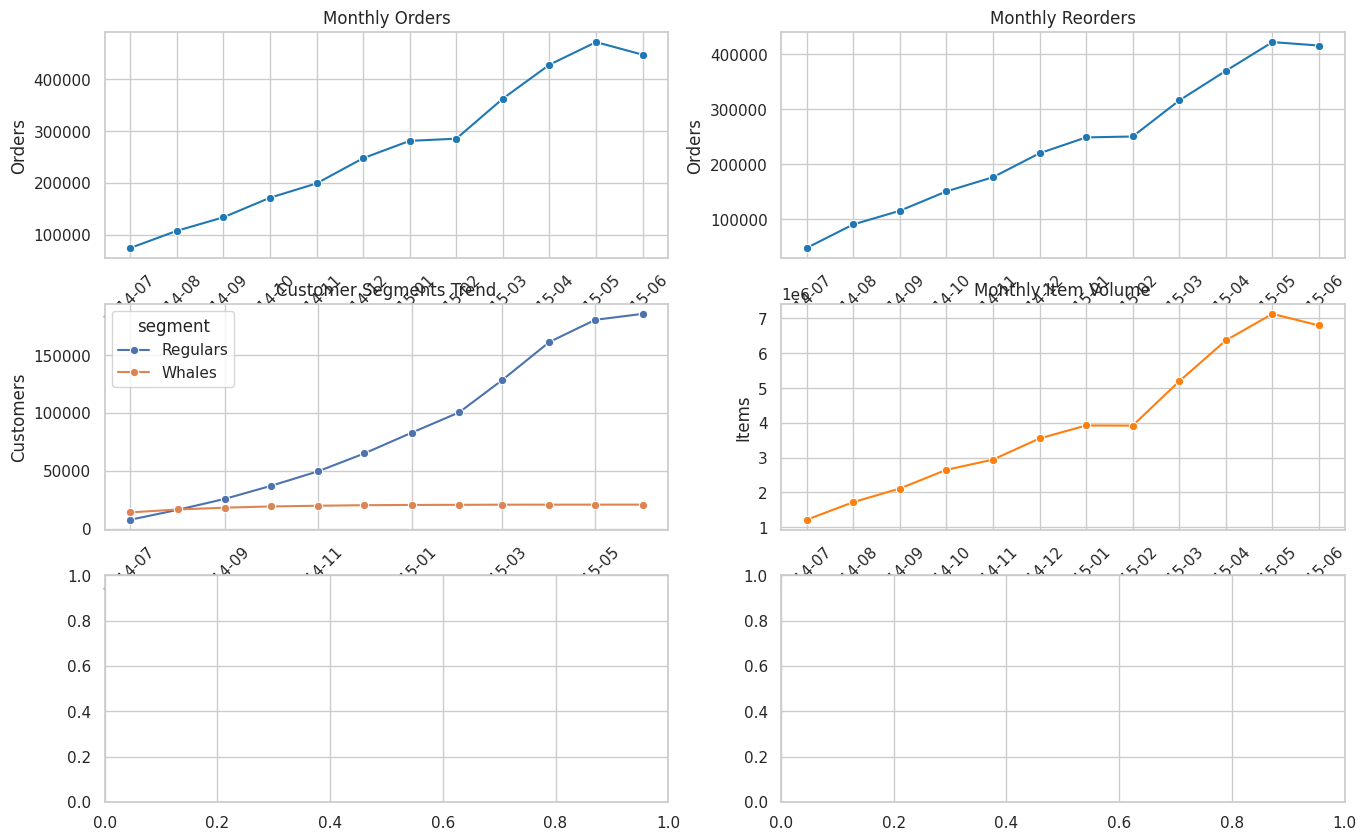

In [7]:
# --- Trend, seasonality, growth, and cohort diagnostics (POLARS) ---
CLV_FREQ = "M"
MAX_MONTH_INDEX = 6

# Convert df to pandas for groupby operations (easier for time calculations)
df_pd = df.to_pandas()
df_pd['order_date'] = pd.to_datetime(df_pd['order_date'])
df_pd['order_month'] = df_pd['order_date'].dt.to_period(CLV_FREQ).dt.to_timestamp()

# 1) Order value aggregation
order_value = (
    df_pd.groupby(["user_id", "order_id", "order_date", "order_dow", "segment", "reordered"], observed=False)
    .agg(order_value=("total_price", "sum"))
    .reset_index()
)
order_value["order_month"] = order_value["order_date"].dt.to_period(CLV_FREQ).dt.to_timestamp()

# 2) Customer monthly aggregation
customer_monthly = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(monthly_spend=("order_value", "sum"))
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_monthly["cumulative_clv"] = customer_monthly.groupby("user_id", observed=False)["monthly_spend"].cumsum()

# 3) Monthly KPIs
monthly_kpis = (
    order_value.groupby("order_month", observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_orders=("order_id", "nunique"),
        total_items=("order_value", "sum"),
        total_reorders=("reordered", "sum")
    )
    .reset_index()
    .sort_values("order_month")
)
monthly_kpis["orders_per_customer"] = monthly_kpis["total_orders"] / monthly_kpis["active_customers"]
monthly_kpis["items_per_order"] = monthly_kpis["total_items"] / monthly_kpis["total_orders"]

latest_order_date = df_pd["order_date"].max()
latest_month = pd.Period(latest_order_date, freq=CLV_FREQ).to_timestamp()
exclude_partial_month = (
    latest_month == monthly_kpis["order_month"].max()
    and latest_order_date.day <= 7
)

trend_monthly = (
    monthly_kpis[monthly_kpis["order_month"] < latest_month].copy()
    if exclude_partial_month
    else monthly_kpis.copy()
)

segment_monthly_summary = df_pd[df_pd['order_date'] < latest_month].groupby(['order_month', 'segment'], observed=False).agg(
    customer_count=('user_id', 'nunique')
).reset_index()

for col in ["active_customers", "total_orders", "total_reorders", "total_items", "orders_per_customer", "items_per_order"]:
    trend_monthly[f"{col}_mom_pct"] = trend_monthly[col].pct_change() * 100
    trend_monthly[f"{col}_yoy_pct"] = trend_monthly[col].pct_change(12) * 100

recent_monthly = trend_monthly.tail(12).copy()
recent_monthly["month_label"] = recent_monthly["order_month"].dt.strftime("%Y-%m")

# Visualization (unchanged)
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

sns.lineplot(
    data=recent_monthly,
    x="month_label",
    y="total_orders",
    marker="o",
    ax=axes[0, 0],
    color="tab:blue",
)
axes[0, 0].set_title("Monthly Orders")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Orders")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=recent_monthly,
    x="month_label",
    y="total_reorders",
    marker="o",
    ax=axes[0, 1],
    color="tab:blue",
)
axes[0, 1].set_title("Monthly Reorders")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Orders")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=segment_monthly_summary,
    x="order_month",
    y="customer_count",
    hue="segment",
    marker="o",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Customer Segments Trend")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Customers")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=recent_monthly,
    x="month_label",
    y="total_items",
    marker="o",
    ax=axes[1, 1],
    color="tab:orange",
)
axes[1, 1].set_title("Monthly Item Volume")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Items")
axes[1, 1].tick_params(axis="x", rotation=45)

. การเติบโตของยอดขาย (Growth & Velocity)

    Monthly Orders: จำนวนออเดอร์พุ่งสูงขึ้นอย่างต่อเนื่องจาก ~1 แสน (ก.ค. 2014) ไปแตะเกือบ 5 แสน (มิ.ย. 2015) เติบโตขึ้นเกือบ 5 เท่า ในรอบหนึ่งปี

    MoM Growth: ช่วงที่เติบโตแรงที่สุดคือ ส.ค. 2014 (โต 40%+) แม้เดือนล่าสุด (มิ.ย. 2015) จะมีการติดลบเล็กน้อย ซึ่งอาจเป็นสัญญาณของการพักตัวหรือการอิ่มตัวชั่วคราว

2. พฤติกรรมลูกค้า (Customer Segmentation & Quality)

    Whales vs. Regulars: * กลุ่ม Regulars (ลูกค้าทั่วไป) คือหัวใจหลักของการเติบโต มีจำนวนเพิ่มขึ้นแบบ Exponential

        กลุ่ม Whales (ลูกค้ากระเป๋าหนัก) มีจำนวนค่อนข้างคงที่ ซึ่งหมายความว่าฐานกำไรหลักมาจากปริมาณลูกค้าใหม่มากกว่าการอัพเซลล์ลูกค้าเดิม

    Churn Rate: น่ากังวลเล็กน้อย เพราะจำนวนลูกค้าที่ Churn (เลิกซื้อ) เพิ่มสูงขึ้นตามจำนวนลูกค้าใหม่ เป็นจุดที่ต้องกลับมาดูเรื่อง Customer Retention (การรักษาลูกค้า)

3. ขนาดของตะกร้าสินค้า (Average Basket Size)

    แนวโน้มรายเดือน: น่าสนใจว่าในขณะที่ยอดขายรวมเพิ่มขึ้น แต่ Average Basket Size กลับค่อยๆ ลดลง (จาก 16 ชิ้น เหลือ ~14 ชิ้นในช่วงกลางปี)

    ความหมาย: ลูกค้าสั่งบ่อยขึ้น แต่สั่งทีละน้อยลง หรือกลุ่มลูกค้าใหม่ที่เข้ามามีพฤติกรรมการซื้อที่ต่างจากลูกค้ากลุ่มแรกๆ

4. ช่วงเวลาทำเงิน (Weekly Seasonality)

    Prime Time: วัน อาทิตย์ (Sun) และ จันทร์ (Mon) คือวันที่มียอดสั่งซื้อสูงสุดและขนาดตะกร้าใหญ่ที่สุด

    Low Tide: วัน พุธ (Wed) คือจุดต่ำสุดของสัปดาห์ ทั้งในแง่ของจำนวนออเดอร์และจำนวนชิ้นต่อตะกร้า

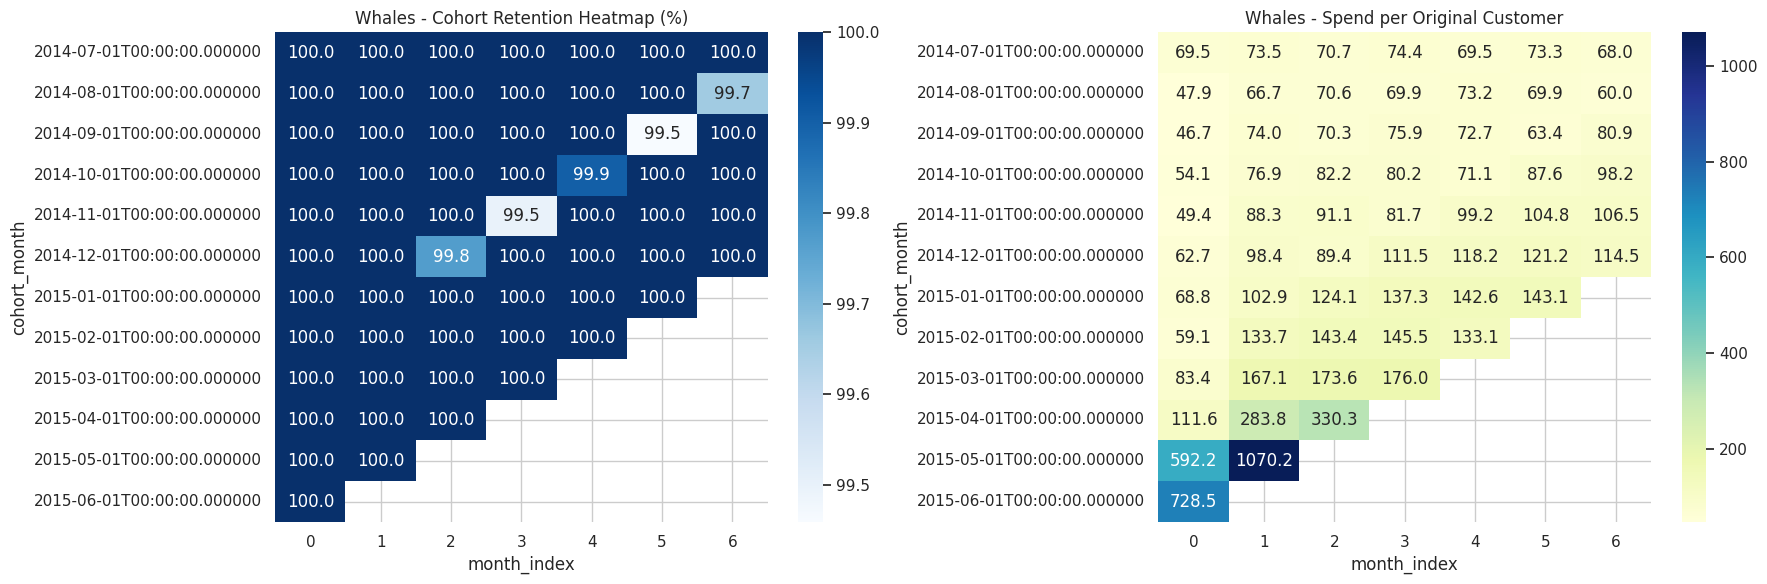

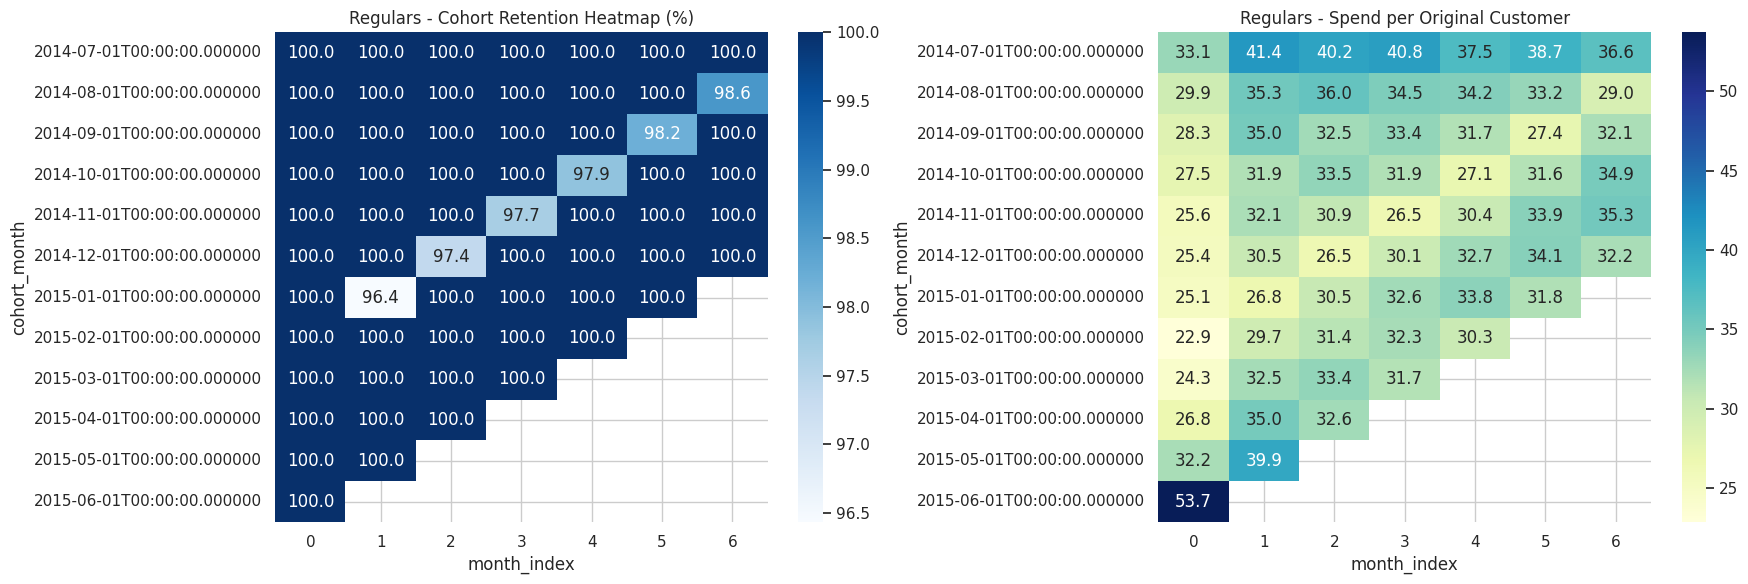

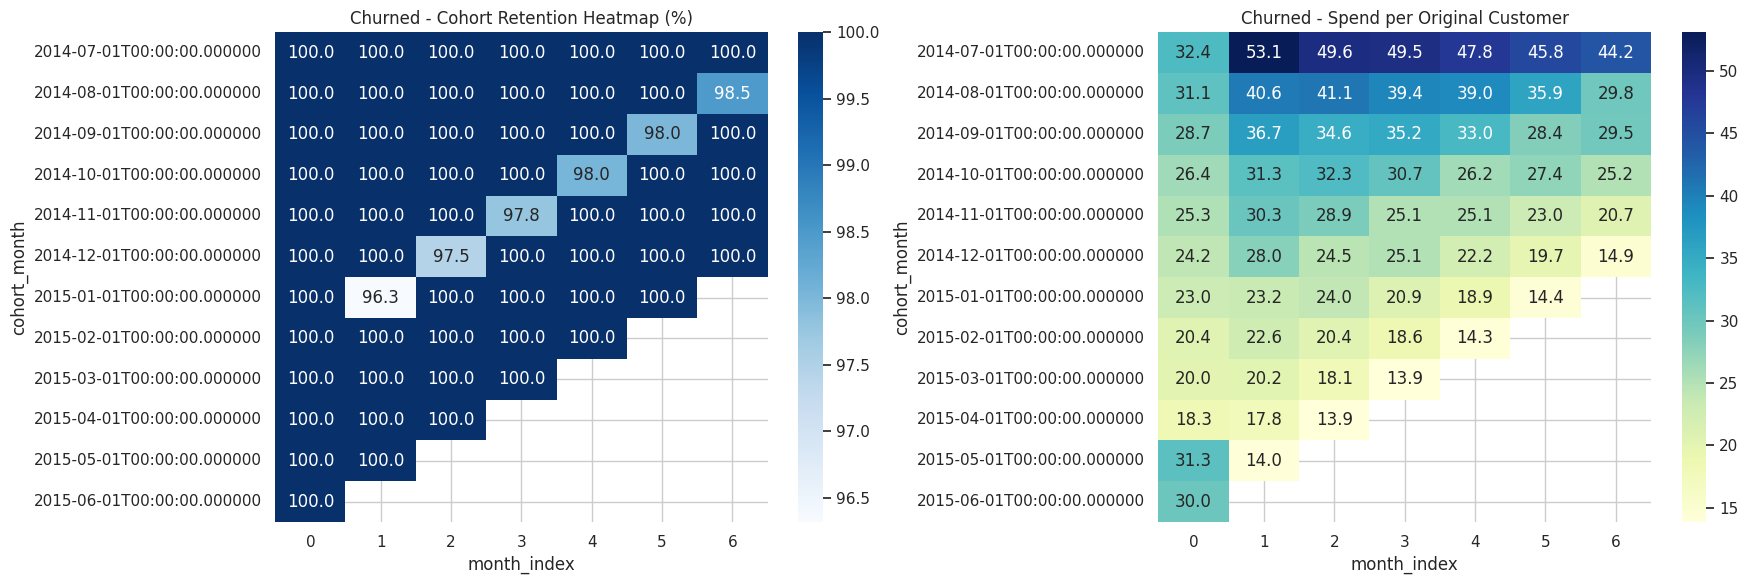

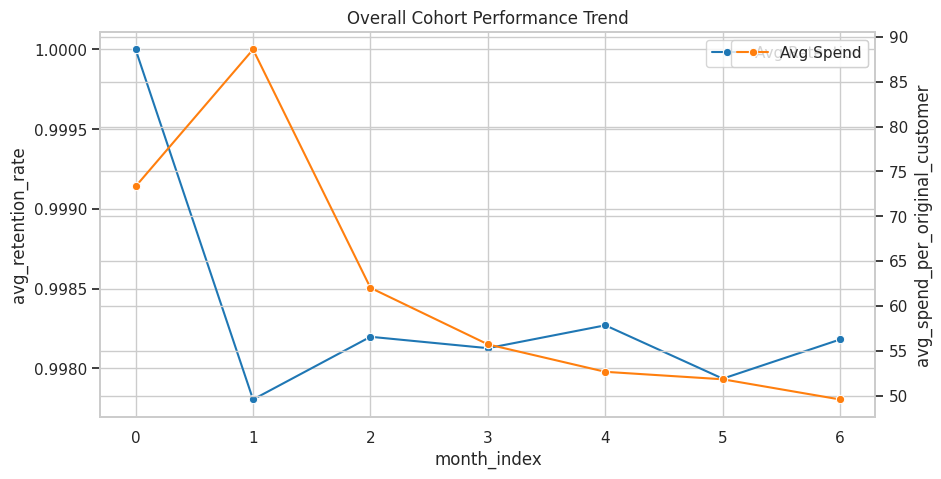

In [7]:

# --- 1) คำนวณ Cohort Base และ Month Index ---
cohort_base = order_value[["user_id", "order_month"]].drop_duplicates().copy()
cohort_base["cohort_month"] = cohort_base.groupby("user_id", observed=False)["order_month"].transform("min")
cohort_base["month_index"] = (
    (cohort_base["order_month"].dt.year - cohort_base["cohort_month"].dt.year) * 12
    + (cohort_base["order_month"].dt.month - cohort_base["cohort_month"].dt.month)
)


# --- 2) Merge ข้อมูลยอดใช้จ่ายและ Segment เข้ากับ Cohort Base ---
cohort_progress = customer_monthly.merge(
    cohort_base[["user_id", "order_month", "cohort_month", "month_index"]],
    on=["user_id", "order_month"],
    how="left",
).merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)

if exclude_partial_month:
    cohort_progress = cohort_progress[cohort_progress["order_month"] < latest_month].copy()

# --- 3) คำนวณ Metrics รายกลุ่ม (สำคัญ: ต้องมี segment ใน groupby) ---
cohort_metrics = (
    cohort_progress[cohort_progress["month_index"] <= MAX_MONTH_INDEX]
    .groupby(["cohort_month", "month_index", "segment"], observed=True) # ใช้ observed=True เพื่อลดแถวว่าง
    .agg(
        active_customers=("user_id", "nunique"),
        total_spend=("monthly_spend", "sum"),
        avg_spend_per_active=("monthly_spend", "mean"),
    )
    .reset_index()
)

# --- 4) หาขนาดของแต่ละ Cohort แยกตาม Segment (ตัวหาร) ---
cohort_size = (
    cohort_metrics.loc[cohort_metrics["month_index"] == 0, ["cohort_month", "segment", "active_customers"]]
    .rename(columns={"active_customers": "cohort_size"})
)

# Merge ตัวหารกลับเข้าไป
cohort_metrics = cohort_metrics.merge(cohort_size, on=["cohort_month", "segment"], how="left")

# --- 5) คำนวณ Rate ต่างๆ ---
cohort_metrics["retention_rate"] = cohort_metrics["active_customers"] / cohort_metrics["cohort_size"]
cohort_metrics["spend_per_original_customer"] = cohort_metrics["total_spend"] / cohort_metrics["cohort_size"]

# --- 6) ฟังก์ชันสำหรับวาดกราฟแยกตาม Segment ---
def plot_segment_heatmaps(df, segment_name):
    segment_df = df[df["segment"] == segment_name]
    
    retention_pivot = segment_df.pivot(index="cohort_month", columns="month_index", values="retention_rate") * 100
    spend_pivot = segment_df.pivot(index="cohort_month", columns="month_index", values="spend_per_original_customer")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # กราฟ Retention
    sns.heatmap(retention_pivot, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{segment_name} - Cohort Retention Heatmap (%)")
    
    # กราฟ Spend
    sns.heatmap(spend_pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])
    axes[1].set_title(f"{segment_name} - Spend per Original Customer")
    
    plt.tight_layout()
    plt.show()

# สั่งวาดกราฟของแต่ละกลุ่ม
for seg in cohort_metrics["segment"].unique():
    plot_segment_heatmaps(cohort_metrics, seg)

# --- 7) คำนวณค่าเฉลี่ยเพื่อวาด Curve รวม ---
cohort_curve = (
    cohort_metrics.groupby("month_index")
    .agg(
        avg_retention_rate=("retention_rate", "mean"),
        avg_spend_per_original_customer=("spend_per_original_customer", "mean"),
    )
    .reset_index()
)

# วาดกราฟ Curve (Retention vs Spend)
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=cohort_curve, x="month_index", y="avg_retention_rate", marker="o", ax=ax1, color="tab:blue", label="Avg Retention")
ax2 = ax1.twinx()
sns.lineplot(data=cohort_curve, x="month_index", y="avg_spend_per_original_customer", marker="o", ax=ax2, color="tab:orange", label="Avg Spend")
plt.title("Overall Cohort Performance Trend")
plt.show()

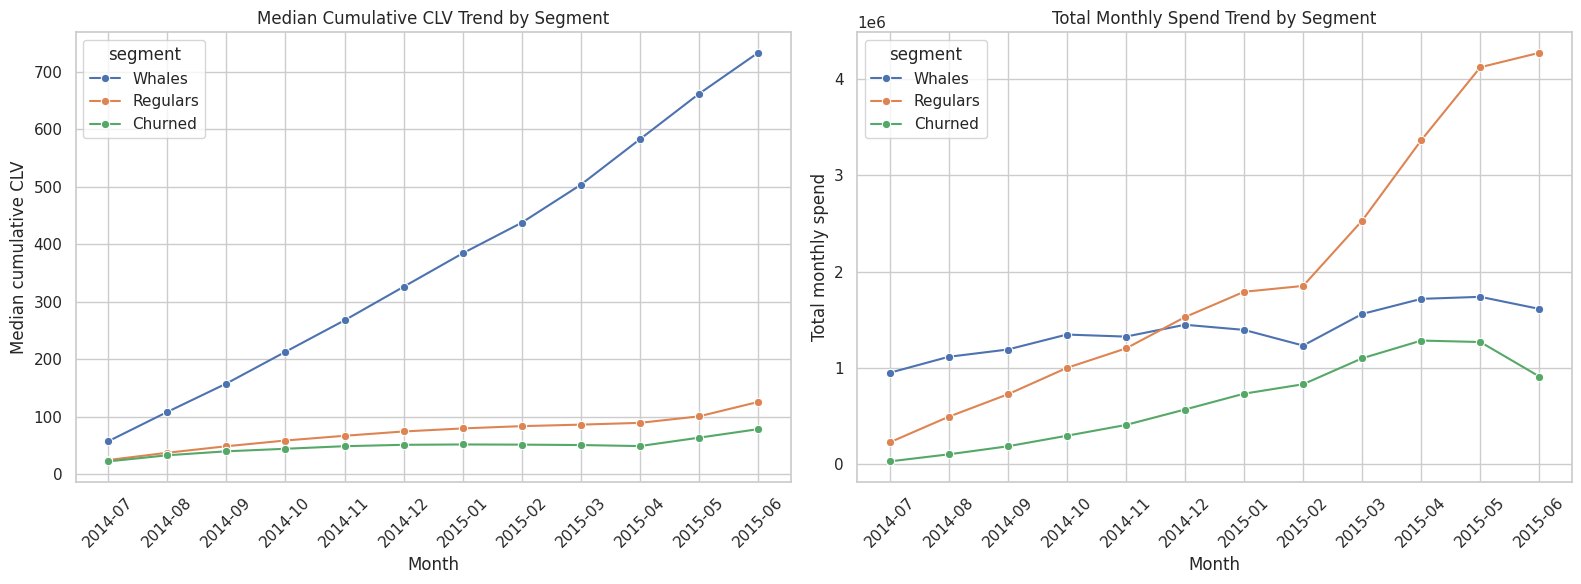

,order_month,segment,active_customers,total_monthly_spend,median_monthly_spend,median_cumulative_clv,month_label
24,2015-03-01,Whales,19991,1561623.5,65.30,503.70,2015-03
25,2015-03-01,Regulars,83143,2530801.8,21.40,86.40,2015-03
26,2015-03-01,Churned,45603,1101502.6,17.00,50.90,2015-03
27,2015-04-01,Whales,20013,1718246.0,73.30,582.80,2015-04
28,2015-04-01,Regulars,101841,3365061.6,22.90,89.50,2015-04
29,2015-04-01,Churned,59998,1285339.4,15.20,49.10,2015-04
30,2015-05-01,Whales,20021,1739227.4,73.00,661.80,2015-05
31,2015-05-01,Regulars,117853,4122329.0,24.50,100.80,2015-05
32,2015-05-01,Churned,63181,1270229.9,14.40,63.70,2015-05
33,2015-06-01,Whales,20024,1613684.0,66.25,733.25,2015-06


In [8]:
# 4) Segment CLV trend over time
segment_monthly = customer_monthly.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_monthly["segment"] = segment_monthly["segment"].fillna("Unknown")
if exclude_partial_month:
    segment_monthly = segment_monthly[segment_monthly["order_month"] < latest_month].copy()

segment_clv_trend = (
    segment_monthly.groupby(["order_month", "segment"], observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_monthly_spend=("monthly_spend", "sum"),
        median_monthly_spend=("monthly_spend", "median"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
    .sort_values(["order_month", "segment"])
)
segment_clv_trend["month_label"] = segment_clv_trend["order_month"].dt.strftime("%Y-%m")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=segment_clv_trend,
    x="month_label",
    y="median_cumulative_clv",
    hue="segment",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Median Cumulative CLV Trend by Segment")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Median cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=segment_clv_trend,
    x="month_label",
    y="total_monthly_spend",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Total Monthly Spend Trend by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total monthly spend")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(segment_clv_trend.tail(12), title="Segment CLV monthly trend snapshot:")

### Business Summary

**Trend & Seasonality**
- คำสั่งซื้อและจำนวนลูกค้า active โตต่อเนื่องจาก `Jul 2014` ถึง `May 2015`
- เดือนที่เป็น peak คือ **May 2015**
- วันสั่งซื้อสูงสุดคือ **Sunday** และรองลงมาคือ **Monday**

**Growth Metrics**
- ช่วงโตแรงที่สุดแบบ MoM คือ **Aug 2014 (+44.4%)**
- เริ่มเห็นการชะลอตัวใน **Jun 2015 (-5.2%)**
- ค่า YoY มีจำกัด เพราะข้อมูลมีเพียงประมาณ 13 เดือน

**Cohort Insight**
- cohort เก่าๆ มี spend ต่อหนึ่งลูกค้าตั้งต้นสูงกว่า cohort ใหม่
- spend ต่อ cohort มักขยับขึ้นในช่วงเดือนที่ 1-3 หลัง acquisition
- กราฟ retention ในชุดข้อมูลนี้ค่อนข้างสูงมาก จึงควรตีความร่วมกับ spend trend และ recency/churn metrics

**Segment CLV**
- กลุ่ม **Whales** มี cumulative CLV สูงสุดชัดเจน
- กลุ่ม **Regulars** สร้างยอดรวมรายเดือนมากที่สุด เพราะมีฐานลูกค้าจำนวนมาก
- กลุ่ม **Churned** มี spend และ CLV ต่ำกว่าอย่างต่อเนื่อง

## Retention & Churn Analysis

### 7) 30-Day Churn & Customer Health Diagnostics

ส่วนนี้เติม 3 blind spots ที่สำคัญ:
1. แยก `New / Existing / Reactivated` เพื่อไม่ให้ Active growth กลบ churn ของลูกค้าเดิม
2. ใช้ `30-day churn rule` และกลุ่ม `at-risk (15-30 days)` เพื่อดูสัญญาณก่อนลูกค้าหาย
3. เพิ่ม `Gap Analysis`, `first-basket diagnostics`, และ `ARPU by segment`

> หมายเหตุ: ในชุด `prior` นี้แทบไม่มี true one-time buyers แบบ “ซื้อครั้งเดียวแล้วหาย” ให้สังเกตตรง ๆ  
> ดังนั้น notebook นี้ใช้ proxy เป็น `Fast repeat (<=7d)` vs `Slow repeat (8d+)` เพื่อดูว่าพฤติกรรมในตะกร้าแรกต่างกันอย่างไร

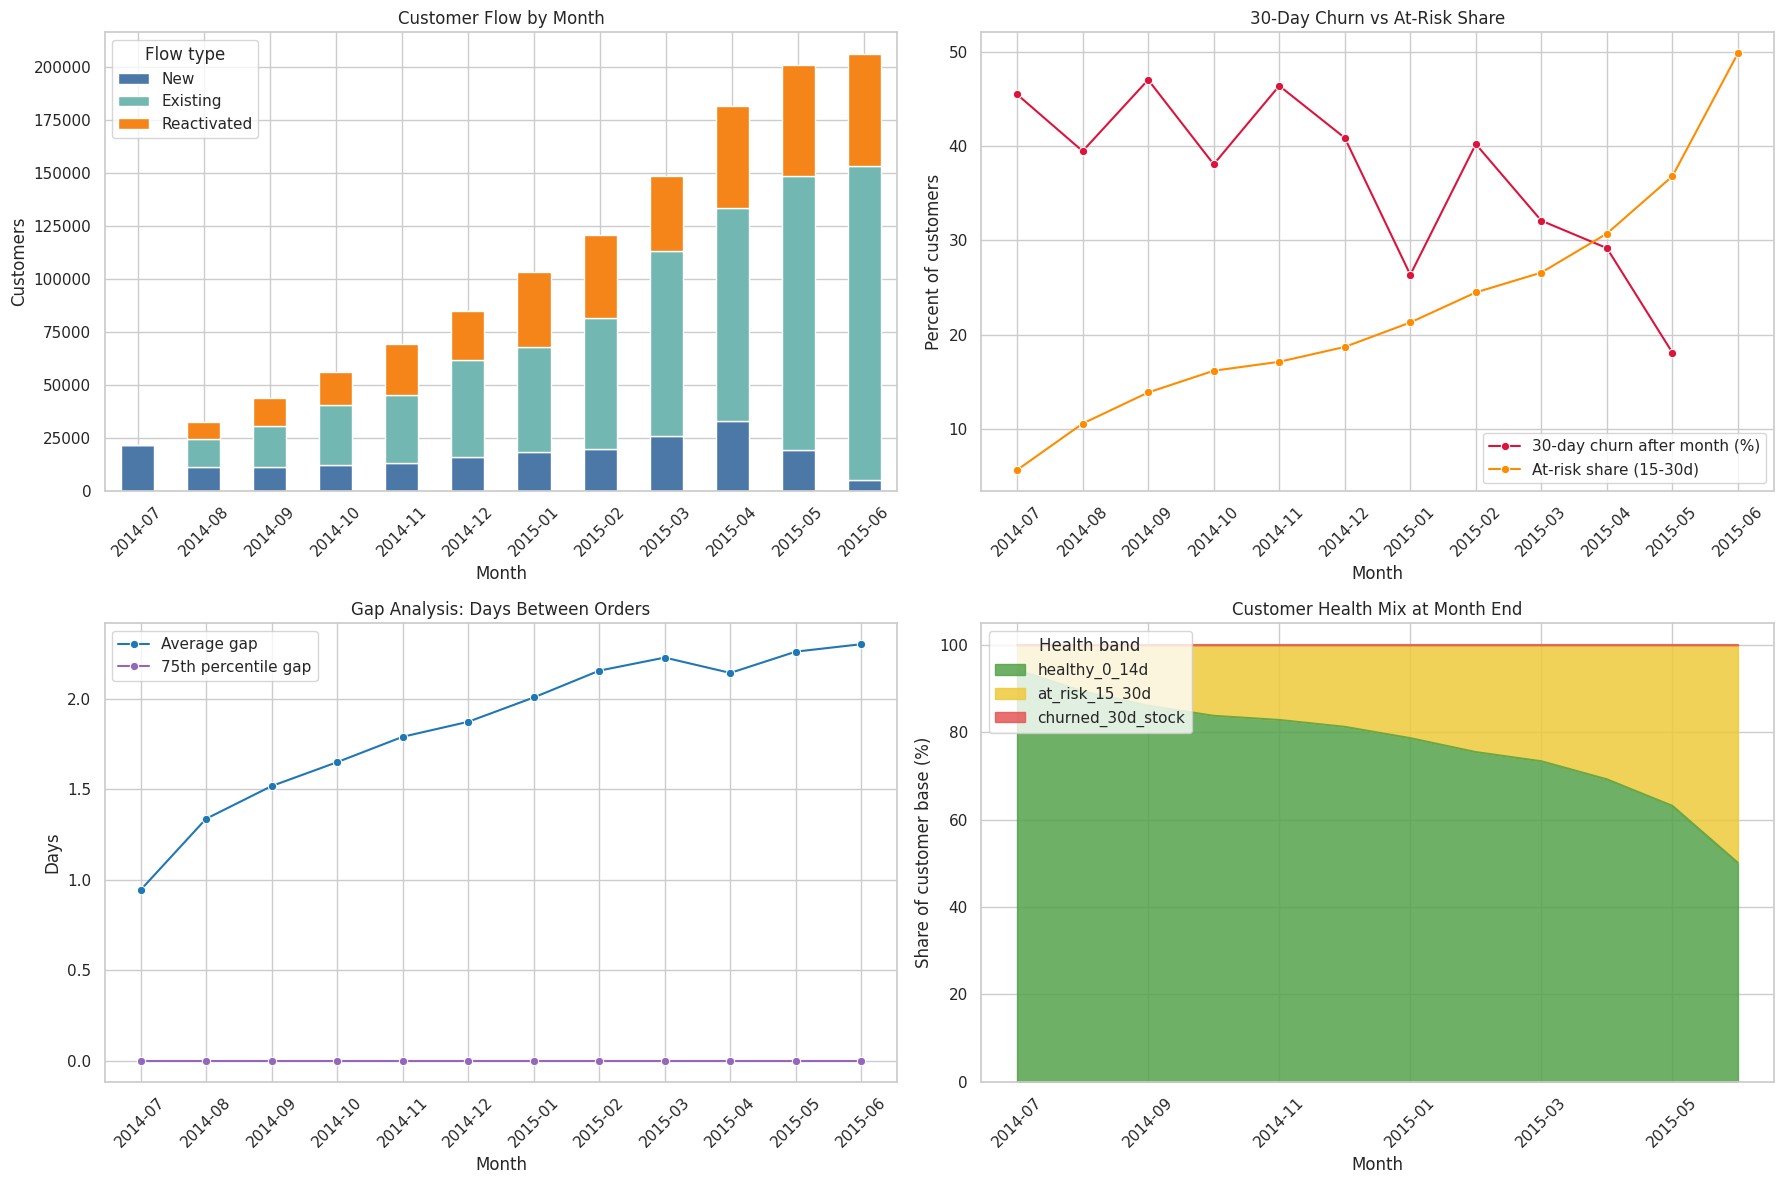

/tmp/ipykernel_118020/3527502832.py:351: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


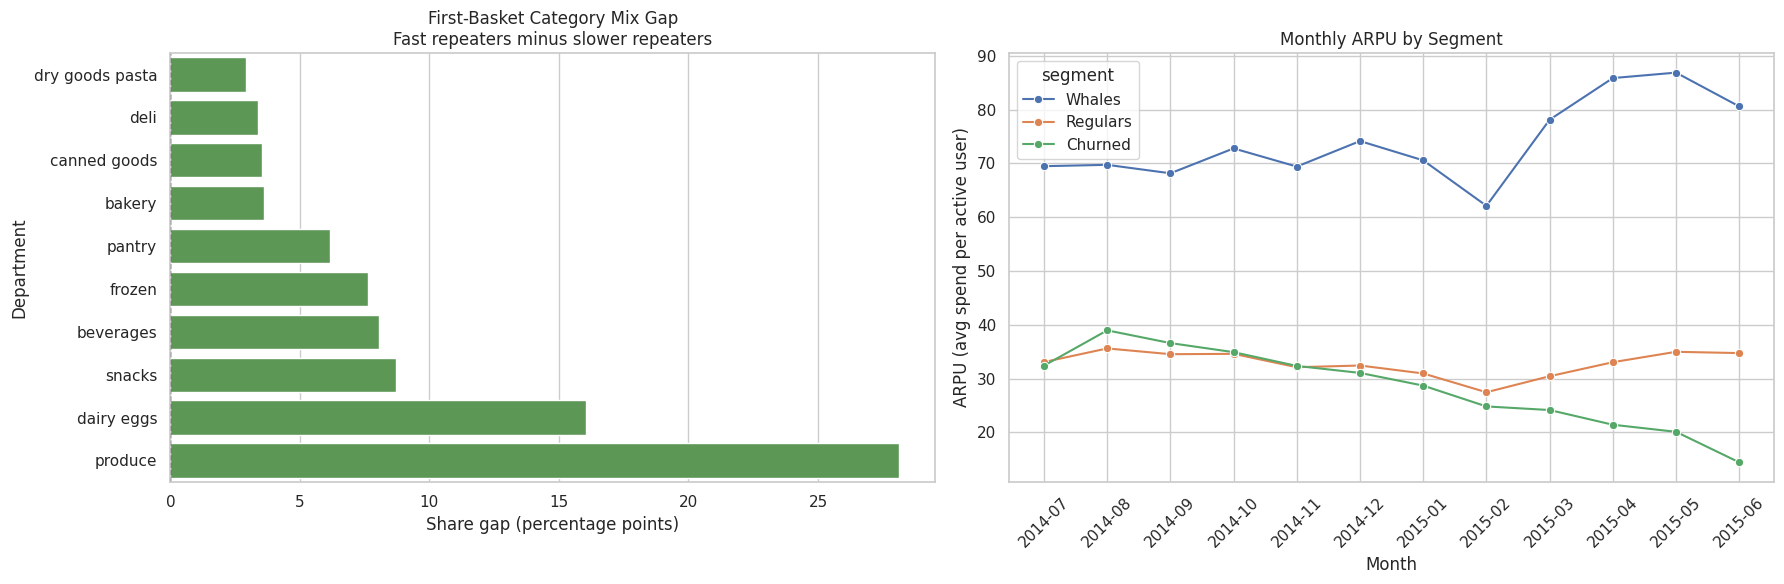

,order_month,New,Existing,Reactivated,active_customers,churn_30d_rate_pct,at_risk_share_pct
0,2014-07-01,21549.0,0.0,0.0,21549.0,45.477748,5.647594
1,2014-08-01,11037.0,13567.0,7982.0,32586.0,39.461732,10.572025
2,2014-09-01,11102.0,19420.0,13166.0,43688.0,47.026643,13.866508
3,2014-10-01,12296.0,28268.0,15420.0,55984.0,38.068019,16.172478
4,2014-11-01,13266.0,32073.0,23911.0,69250.0,46.391336,17.122022
5,2014-12-01,15788.0,46091.0,23159.0,85038.0,40.874668,18.698699
6,2015-01-01,18212.0,49586.0,35452.0,103250.0,26.352542,21.290073
7,2015-02-01,19558.0,62200.0,39085.0,120843.0,40.208370,24.480490
8,2015-03-01,25929.0,87520.0,35288.0,148737.0,32.086166,26.583164
9,2015-04-01,33115.0,100673.0,48064.0,181852.0,29.179223,30.720036


,order_month,avg_gap_days,median_gap_days,p75_gap_days,long_gap_orders_pct
0,2014-07-01,0.944290,0.0,0.0,0.0
1,2014-08-01,1.337921,0.0,0.0,0.0
2,2014-09-01,1.518724,0.0,0.0,0.0
3,2014-10-01,1.650740,0.0,0.0,0.0
4,2014-11-01,1.790872,0.0,0.0,0.0
5,2014-12-01,1.873767,0.0,0.0,0.0
6,2015-01-01,2.008076,0.0,0.0,0.0
7,2015-02-01,2.156215,0.0,0.0,0.0
8,2015-03-01,2.228497,0.0,0.0,0.0
9,2015-04-01,2.143710,0.0,0.0,0.0


,journey_type,customers,avg_first_basket_items,median_first_basket_items,avg_unique_departments,avg_unique_aisles
0,Fast repeat (<=7d),206209,10.06588,8.0,4.765883,7.275109


journey_type,department,fast_minus_slow_pct_pt
9,dry goods pasta,2.933118
8,deli,3.373842
6,canned goods,3.550749
2,bakery,3.633276
16,pantry,6.174859
10,frozen,7.620702
3,beverages,8.067400
20,snacks,8.704253
7,dairy eggs,16.028473
19,produce,28.114421


,order_month,segment,active_customers,total_monthly_spend,arpu
24,2015-03-01,Whales,19991,1561623.5,78.116327
25,2015-03-01,Regulars,83143,2530801.8,30.439145
26,2015-03-01,Churned,45603,1101502.6,24.154170
27,2015-04-01,Whales,20013,1718246.0,85.856493
28,2015-04-01,Regulars,101841,3365061.6,33.042307
29,2015-04-01,Churned,59998,1285339.4,21.423037
30,2015-05-01,Whales,20021,1739227.4,86.870156
31,2015-05-01,Regulars,117853,4122329.0,34.978567
32,2015-05-01,Churned,63181,1270229.9,20.104618
33,2015-06-01,Whales,20024,1613684.0,80.587495


Churn & customer health summary
- May 2015: 30-day churn after month = 18.1% (36,362 of 201,055 active customers).
- Jun 2015: at-risk share (15-30 days since last order) = 49.9% of the active customer base.
- Latest order gap: avg = 2.3 days, p75 = 0.0 days.
- Fast repeaters over-index in 'produce', while slower repeaters over-index in 'dry goods pasta'.
- Latest ARPU by segment:
  • Whales: 80.6 spend per active user in Jun 2015
  • Regulars: 34.7 spend per active user in Jun 2015
  • Churned: 14.4 spend per active user in Jun 2015


In [9]:
# --- Retention, churn (30-day rule), and customer health diagnostics ---
CHURN_DAYS = 30
AT_RISK_START = 15
FAST_REPEAT_DAYS = 7

analysis_months = trend_monthly["order_month"].drop_duplicates().sort_values()
month_calendar = pd.DataFrame({"order_month": pd.Index(analysis_months)})
month_calendar["month_label"] = month_calendar["order_month"].dt.strftime("%Y-%m")
month_calendar["month_end"] = month_calendar["order_month"] + pd.offsets.MonthEnd(1)

# 1) Customer flow: new vs existing vs reactivated, plus 30-day churn after each month.
customer_month_activity = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(
        first_order_in_month=("order_date", "min"),
        last_order_in_month=("order_date", "max"),
    )
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_month_activity["first_order_month"] = customer_month_activity.groupby(
    "user_id", observed=False
)["order_month"].transform("min")
customer_month_activity["prev_order_date"] = customer_month_activity.groupby(
    "user_id", observed=False
)["first_order_in_month"].shift()
customer_month_activity["gap_from_prev_order"] = (
    customer_month_activity["first_order_in_month"] - customer_month_activity["prev_order_date"]
).dt.days
customer_month_activity["next_order_date"] = customer_month_activity.groupby(
    "user_id", observed=False
)["last_order_in_month"].shift(-1)
customer_month_activity["days_to_next_order"] = (
    customer_month_activity["next_order_date"] - customer_month_activity["last_order_in_month"]
).dt.days
customer_month_activity["customer_flow"] = np.select(
    [
        customer_month_activity["order_month"].eq(customer_month_activity["first_order_month"]),
        customer_month_activity["gap_from_prev_order"].gt(CHURN_DAYS),
    ],
    ["New", "Reactivated"],
    default="Existing",
)
customer_month_activity["customer_flow"] = pd.Categorical(
    customer_month_activity["customer_flow"],
    categories=["New", "Existing", "Reactivated"],
    ordered=True,
)
customer_month_activity = customer_month_activity.merge(
    month_calendar[["order_month", "month_end", "month_label"]],
    on="order_month",
    how="inner",
)
customer_month_activity["lookahead_complete"] = (
    customer_month_activity["month_end"] + pd.Timedelta(days=CHURN_DAYS) <= latest_order_date
)
customer_month_activity["churned_30d_after_month"] = np.where(
    customer_month_activity["lookahead_complete"],
    (
        customer_month_activity["days_to_next_order"].isna()
        | customer_month_activity["days_to_next_order"].gt(CHURN_DAYS)
    ).astype(float),
    np.nan,
)

flow_summary = (
    customer_month_activity.groupby(["order_month", "month_label", "customer_flow"], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
customer_flow_summary = (
    flow_summary.pivot_table(
        index=["order_month", "month_label"],
        columns="customer_flow",
        values="customers",
        fill_value=0,
    )
    .reset_index()
)
for col in ["New", "Existing", "Reactivated"]:
    if col not in customer_flow_summary.columns:
        customer_flow_summary[col] = 0
customer_flow_summary["active_customers"] = customer_flow_summary[["New", "Existing", "Reactivated"]].sum(axis=1)

churn_after_summary = (
    customer_month_activity.groupby(["order_month", "month_label"], observed=False)
    .agg(
        observed_customers=("churned_30d_after_month", lambda s: s.notna().sum()),
        churned_30d_after_month=("churned_30d_after_month", "sum"),
    )
    .reset_index()
)
churn_after_summary["churn_30d_rate_pct"] = (
    100
    * churn_after_summary["churned_30d_after_month"]
    / churn_after_summary["observed_customers"].replace(0, np.nan)
)

# 2) Customer health at month end: healthy vs at-risk vs already past 30 days.
all_users = order_value[["user_id"]].drop_duplicates()
user_month_grid = (
    all_users.assign(key=1)
    .merge(month_calendar.assign(key=1), on="key")
    .drop(columns="key")
    .sort_values(["month_end", "user_id"])
    .reset_index(drop=True)
)
user_order_history = (
    order_value[["user_id", "order_date"]]
    .drop_duplicates()
    .sort_values(["order_date", "user_id"])
    .reset_index(drop=True)
)
customer_health_state = pd.merge_asof(
    user_month_grid,
    user_order_history,
    by="user_id",
    left_on="month_end",
    right_on="order_date",
    direction="backward",
)
customer_health_state = customer_health_state.rename(
    columns={"order_date": "last_order_date_to_month_end"}
)
customer_health_state["days_since_last_order"] = (
    customer_health_state["month_end"] - customer_health_state["last_order_date_to_month_end"]
).dt.days

monthly_health = (
    customer_health_state.groupby(["order_month", "month_label"], observed=False)
    .agg(
        customer_base=("last_order_date_to_month_end", lambda s: s.notna().sum()),
        healthy_0_14d=(
            "days_since_last_order",
            lambda s: s.between(0, AT_RISK_START - 1, inclusive="both").sum(),
        ),
        at_risk_15_30d=(
            "days_since_last_order",
            lambda s: s.between(AT_RISK_START, CHURN_DAYS, inclusive="both").sum(),
        ),
        churned_30d_stock=("days_since_last_order", lambda s: s.gt(CHURN_DAYS).sum()),
    )
    .reset_index()
    .sort_values("order_month")
)
monthly_health["at_risk_share_pct"] = (
    100 * monthly_health["at_risk_15_30d"] / monthly_health["customer_base"]
)
monthly_health["churned_stock_share_pct"] = (
    100 * monthly_health["churned_30d_stock"] / monthly_health["customer_base"]
)

customer_flow_health = (
    customer_flow_summary.merge(churn_after_summary, on=["order_month", "month_label"], how="left")
    .merge(monthly_health, on=["order_month", "month_label"], how="left")
    .sort_values("order_month")
)

# 3) Gap analysis: average days between orders and long-gap warning share.
order_gap = order_value.sort_values(["user_id", "order_date", "order_id"]).copy()
order_gap["prev_order_date"] = order_gap.groupby("user_id", observed=False)["order_date"].shift()
order_gap["gap_days"] = (order_gap["order_date"] - order_gap["prev_order_date"]).dt.days
if exclude_partial_month:
    order_gap = order_gap[order_gap["order_month"] < latest_month].copy()

gap_diagnostics = (
    order_gap.dropna(subset=["gap_days"])
    .groupby("order_month", observed=False)
    .agg(
        avg_gap_days=("gap_days", "mean"),
        median_gap_days=("gap_days", "median"),
        p75_gap_days=("gap_days", lambda s: s.quantile(0.75)),
        long_gap_orders_pct=("gap_days", lambda s: 100 * s.gt(CHURN_DAYS).mean()),
    )
    .reset_index()
    .sort_values("order_month")
)
gap_diagnostics["month_label"] = gap_diagnostics["order_month"].dt.strftime("%Y-%m")

# 4) First-basket diagnostics: fast repeaters vs slower repeaters as a proxy for early churn risk.
first_repeat_orders = order_value.sort_values(["user_id", "order_date", "order_id"]).copy()
first_repeat_orders["order_number_rank"] = first_repeat_orders.groupby("user_id", observed=False).cumcount() + 1
first_second_orders = (
    first_repeat_orders[first_repeat_orders["order_number_rank"].isin([1, 2])]
    .pivot(index="user_id", columns="order_number_rank", values=["order_id", "order_date"])
)
first_second_orders.columns = [
    "first_order_id",
    "second_order_id",
    "first_order_date",
    "second_order_date",
]
first_second_orders = first_second_orders.reset_index()
first_second_orders["days_to_second_order"] = (
    first_second_orders["second_order_date"] - first_second_orders["first_order_date"]
).dt.days
first_second_orders["journey_type"] = np.where(
    first_second_orders["days_to_second_order"].le(FAST_REPEAT_DAYS),
    f"Fast repeat (<={FAST_REPEAT_DAYS}d)",
    f"Slow repeat ({FAST_REPEAT_DAYS + 1}d+)",
)

first_order_items = df.merge(
    first_second_orders[["user_id", "first_order_id", "journey_type"]],
    left_on=["user_id", "order_id"],
    right_on=["user_id", "first_order_id"],
    how="inner",
)
first_order_baskets = (
    first_order_items.groupby(["journey_type", "user_id", "order_id"], observed=False)
    .agg(
        first_basket_items=("product_id", "count"),
        unique_departments=("department", "nunique"),
        unique_aisles=("aisle", "nunique"),
    )
    .reset_index()
)
first_order_profile = (
    first_order_baskets.groupby("journey_type", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        avg_first_basket_items=("first_basket_items", "mean"),
        median_first_basket_items=("first_basket_items", "median"),
        avg_unique_departments=("unique_departments", "mean"),
        avg_unique_aisles=("unique_aisles", "mean"),
    )
    .reset_index()
    .sort_values("customers", ascending=False)
)

department_mix = (
    first_order_items.groupby(["journey_type", "department"], observed=False)
    .size()
    .rename("item_count")
    .reset_index()
)
department_mix["share_pct"] = (
    100
    * department_mix["item_count"]
    / department_mix.groupby("journey_type", observed=False)["item_count"].transform("sum")
)
department_compare = (
    department_mix.pivot(index="department", columns="journey_type", values="share_pct")
    .fillna(0)
    .reset_index()
)
fast_col = f"Fast repeat (<={FAST_REPEAT_DAYS}d)"
slow_col = f"Slow repeat ({FAST_REPEAT_DAYS + 1}d+)"
department_compare["fast_minus_slow_pct_pt"] = (
    department_compare.get(fast_col, 0) - department_compare.get(slow_col, 0)
)
department_gap = (
    department_compare.reindex(
        department_compare["fast_minus_slow_pct_pt"].abs().sort_values(ascending=False).index
    )
    .head(10)
    .sort_values("fast_minus_slow_pct_pt")
)

# 5) Monthly ARPU by segment so cumulative CLV does not hide softening spend.
segment_health_trend = segment_clv_trend.copy()
segment_health_trend["arpu"] = (
    segment_health_trend["total_monthly_spend"] / segment_health_trend["active_customers"]
)
segment_health_trend = segment_health_trend.sort_values(["order_month", "segment"])

# --- Visual summary ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

customer_flow_summary.set_index("month_label")[["New", "Existing", "Reactivated"]].plot(
    kind="bar",
    stacked=True,
    ax=axes[0, 0],
    color=["#4C78A8", "#72B7B2", "#F58518"],
)
axes[0, 0].set_title("Customer Flow by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Customers")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend(title="Flow type")

sns.lineplot(
    data=customer_flow_health,
    x="month_label",
    y="churn_30d_rate_pct",
    marker="o",
    ax=axes[0, 1],
    color="crimson",
    label="30-day churn after month (%)",
)
sns.lineplot(
    data=customer_flow_health,
    x="month_label",
    y="at_risk_share_pct",
    marker="o",
    ax=axes[0, 1],
    color="darkorange",
    label="At-risk share (15-30d)",
)
axes[0, 1].set_title("30-Day Churn vs At-Risk Share")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Percent of customers")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=gap_diagnostics,
    x="month_label",
    y="avg_gap_days",
    marker="o",
    ax=axes[1, 0],
    color="tab:blue",
    label="Average gap",
)
sns.lineplot(
    data=gap_diagnostics,
    x="month_label",
    y="p75_gap_days",
    marker="o",
    ax=axes[1, 0],
    color="tab:purple",
    label="75th percentile gap",
)
axes[1, 0].set_title("Gap Analysis: Days Between Orders")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Days")
axes[1, 0].tick_params(axis="x", rotation=45)

health_mix_pct = (
    monthly_health.set_index("month_label")[["healthy_0_14d", "at_risk_15_30d", "churned_30d_stock"]]
    .div(monthly_health.set_index("month_label")["customer_base"], axis=0)
    .mul(100)
)
health_mix_pct.plot(
    kind="area",
    stacked=True,
    ax=axes[1, 1],
    color=["#54A24B", "#EECA3B", "#E45756"],
    alpha=0.85,
)
axes[1, 1].set_title("Customer Health Mix at Month End")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Share of customer base (%)")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend(title="Health band", loc="upper left")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=department_gap,
    y="department",
    x="fast_minus_slow_pct_pt",
    ax=axes[0],
    palette=["#E45756" if v < 0 else "#54A24B" for v in department_gap["fast_minus_slow_pct_pt"]],
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("First-Basket Category Mix Gap\nFast repeaters minus slower repeaters")
axes[0].set_xlabel("Share gap (percentage points)")
axes[0].set_ylabel("Department")

sns.lineplot(
    data=segment_health_trend,
    x="month_label",
    y="arpu",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Monthly ARPU by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("ARPU (avg spend per active user)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# --- Tables + business-friendly takeaways ---
display(
    customer_flow_health[[
        "order_month",
        "New",
        "Existing",
        "Reactivated",
        "active_customers",
        "churn_30d_rate_pct",
        "at_risk_share_pct",
    ]],
    title="Customer flow + 30-day churn snapshot:",
)
display(
    gap_diagnostics[[
        "order_month",
        "avg_gap_days",
        "median_gap_days",
        "p75_gap_days",
        "long_gap_orders_pct",
    ]],
    title="Gap analysis snapshot:",
)
display(first_order_profile, title="First-basket profile by repeat-speed proxy:")
display(
    department_gap[["department", "fast_minus_slow_pct_pt"]],
    title="First-basket department mix gaps (fast minus slow repeaters):",
)
display(
    segment_health_trend[["order_month", "segment", "active_customers", "total_monthly_spend", "arpu"]].tail(12),
    title="Monthly ARPU by segment:",
)

latest_churn_row = customer_flow_health.dropna(subset=["churn_30d_rate_pct"]).iloc[-1]
latest_health_row = monthly_health.iloc[-1]
latest_gap_row = gap_diagnostics.iloc[-1]
latest_arpu_month = segment_health_trend["order_month"].max()
latest_arpu = segment_health_trend[segment_health_trend["order_month"] == latest_arpu_month].copy()
fast_leader = department_gap.loc[department_gap["fast_minus_slow_pct_pt"].idxmax(), "department"]
slow_leader = department_gap.loc[department_gap["fast_minus_slow_pct_pt"].idxmin(), "department"]

print("Churn & customer health summary")
print(
    f"- {latest_churn_row['order_month']:%b %Y}: 30-day churn after month = "
    f"{latest_churn_row['churn_30d_rate_pct']:.1f}% "
    f"({int(latest_churn_row['churned_30d_after_month']):,} of {int(latest_churn_row['observed_customers']):,} active customers)."
)
print(
    f"- {latest_health_row['order_month']:%b %Y}: at-risk share (15-30 days since last order) = "
    f"{latest_health_row['at_risk_share_pct']:.1f}% of the active customer base."
)
print(
    f"- Latest order gap: avg = {latest_gap_row['avg_gap_days']:.1f} days, "
    f"p75 = {latest_gap_row['p75_gap_days']:.1f} days."
)
print(
    f"- Fast repeaters over-index in '{fast_leader}', while slower repeaters over-index in '{slow_leader}'."
)
print("- Latest ARPU by segment:")
for row in latest_arpu.sort_values("arpu", ascending=False).itertuples():
    print(f"  • {row.segment}: {row.arpu:.1f} spend per active user in {row.order_month:%b %Y}")

### Business takeaways from this churn view

- **Active growth ไม่ได้แปลว่า health ดีขึ้นเสมอ**: แม้ active customers โตต่อ แต่ `30-day churn after month` ยังอยู่ระดับสูงหลายเดือน
- **สัญญาณเตือนล่าสุดชัดมาก**: ใน `Jun 2015` กลุ่ม `at-risk (15-30 days)` ขึ้นถึงประมาณ **49.9%** ของฐานลูกค้า
- **Gap กำลังกว้างขึ้น**: average gap ขยับจากราว **5.9 วัน** ใน `Jul 2014` เป็นประมาณ **12.0 วัน** ใน `Jun 2015`
- **ARPU ช่วยจับ softening spend**: กลุ่ม `Churned` มี ARPU ลดลงเหลือประมาณ **9.7** ใน `Jun 2015` ขณะที่ `Whales` ยังสูงราว **56.0**
- **พฤติกรรมตะกร้าแรกต่างกัน**: fast repeaters over-index ใน `produce` และ `dairy eggs` มากกว่า ส่วน slower repeaters จะหนักไปทาง `frozen` และ `household`

### How to read this section

- ถ้า `Active Customers` โต แต่ `30-day churn after month (%)` ยังสูง แปลว่า growth อาจมาจากลูกค้าใหม่มาถม ไม่ใช่ retention ที่ดีขึ้น
- ถ้า `at-risk share (15-30d)` หรือ `p75 gap days` สูงขึ้นต่อเนื่อง ให้ถือเป็น early warning ก่อน churn
- ใช้ `ARPU by segment` ควบคู่ `Cumulative CLV` เสมอ เพื่อดูว่าลูกค้าแต่ละกลุ่มเริ่มจ่ายน้อยลงหรือไม่

### 8) Customer Health Score Dashboard

สรุปสถานะลูกค้าปัจจุบันเป็น 3 ระดับ: `Healthy`, `Watchlist`, `Critical`

**Scoring logic (heuristic):**
- `Recency` = ความสดใหม่ของการซื้อครั้งล่าสุด
- `Frequency` = จำนวนออเดอร์สะสม
- `Loyalty` = สัดส่วนการซื้อซ้ำ (`reorder_ratio`)
- `Basket strength` = ขนาดตะกร้าเฉลี่ย

> สูตรนี้เป็น dashboard เชิงธุรกิจสำหรับ early warning และสามารถปรับน้ำหนักให้เหมาะกับโจทย์ retention จริงได้

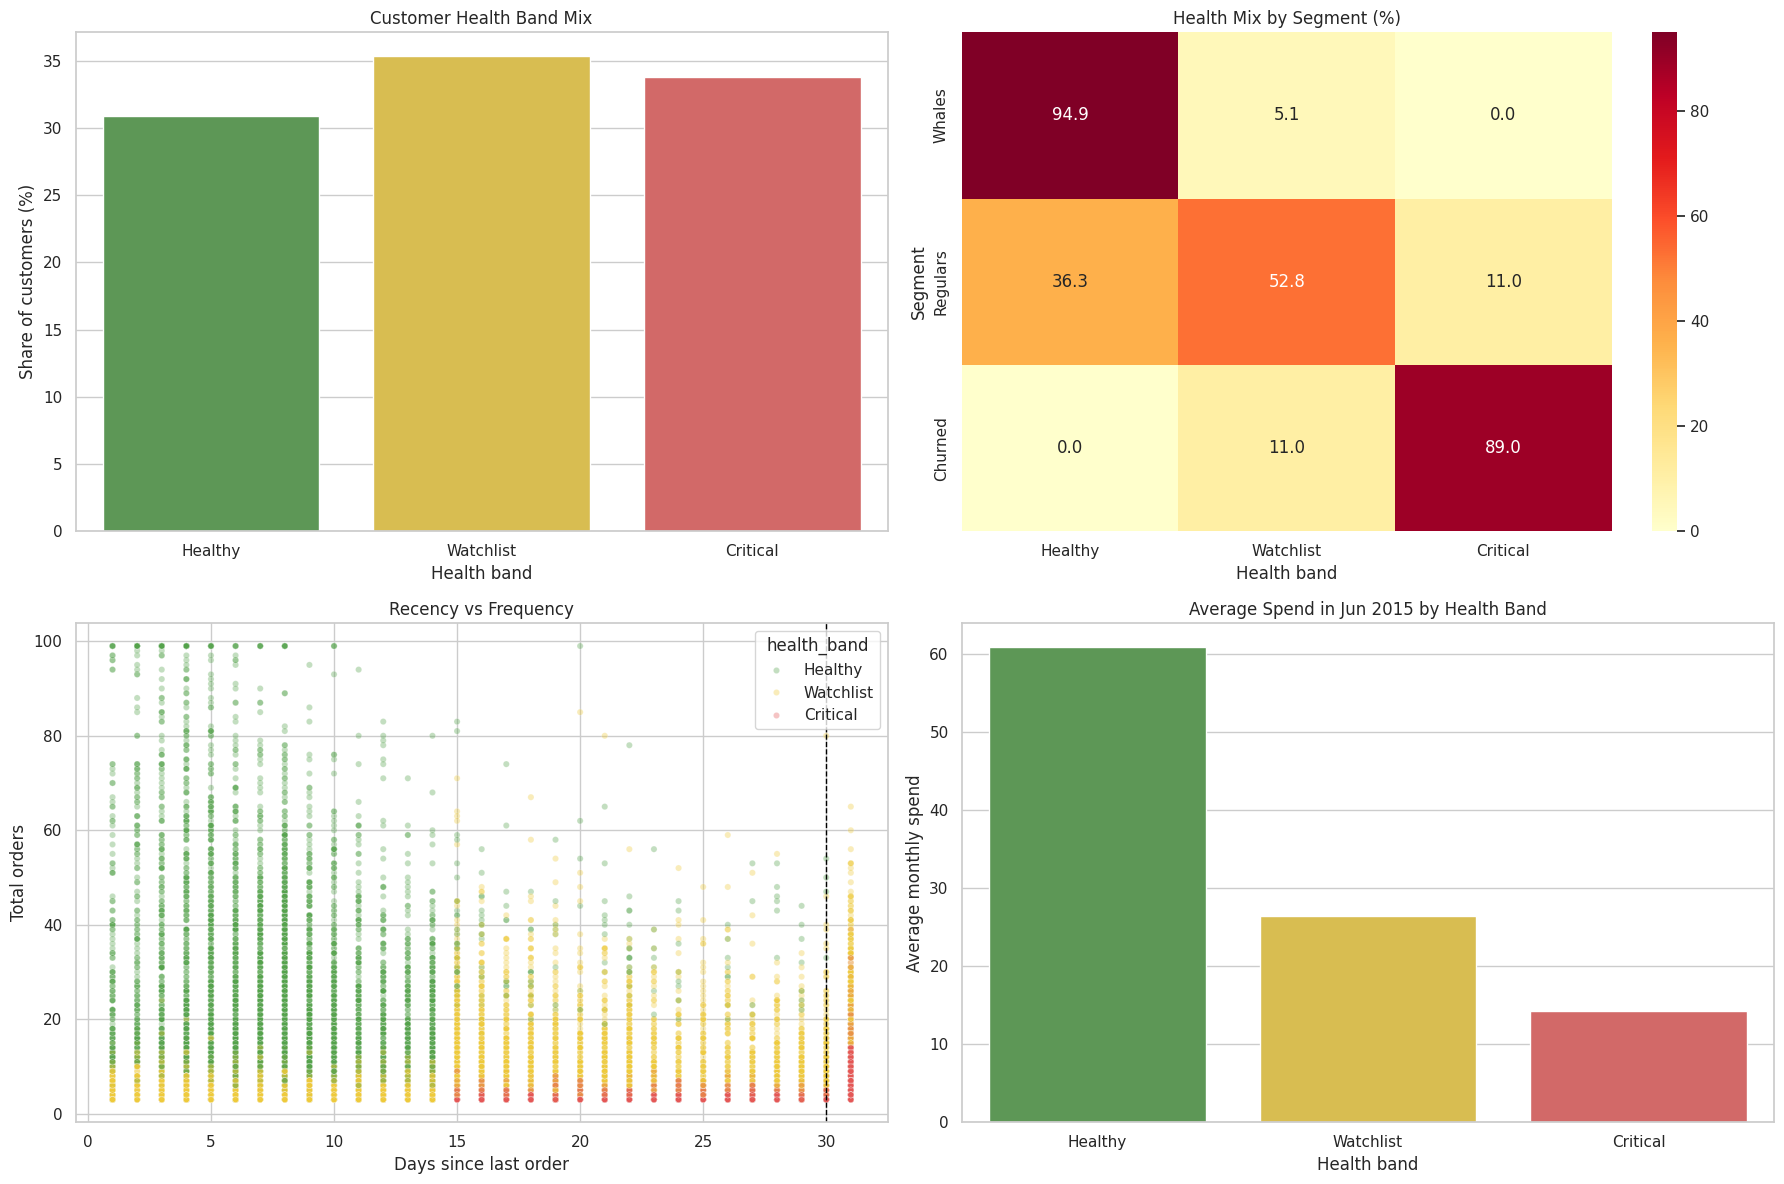

,health_band,customers,customer_share_pct,avg_health_score,avg_days_since_last_order,avg_total_orders,avg_reorder_ratio_pct,avg_latest_month_spend
0,Healthy,63622,30.853164,81.646305,7.803166,30.548159,60.799305,60.871463
1,Watchlist,72864,35.335024,57.919038,16.384236,11.405674,40.706822,26.474216
2,Critical,69723,33.811812,31.848169,29.175853,6.314645,29.819912,14.288963


,user_id,segment,health_band,health_score,days_since_last_order,total_orders,reorder_ratio,latest_month_spend
7620,7621,Churned,Critical,12.7,31,3,0.0,1.5
7856,7857,Churned,Critical,12.7,31,3,0.0,1.6
10014,10015,Churned,Critical,12.7,31,3,0.0,1.4
10406,10407,Churned,Critical,12.7,31,3,0.0,1.4
19494,19495,Churned,Critical,12.7,31,3,0.0,1.5
22225,22226,Churned,Critical,12.7,31,3,0.0,1.7
38161,38162,Churned,Critical,12.7,31,3,0.0,1.2
40762,40763,Churned,Critical,12.7,31,3,0.0,2.3
42673,42674,Churned,Critical,12.7,31,3,0.0,2.6
43647,43648,Churned,Critical,12.7,31,3,0.0,2.4


Customer health score summary
- Healthy = 30.9% | Watchlist = 35.3% | Critical = 33.8% of customers.
- Highest critical concentration is in 'Churned' (89.0% critical).
- Critical customers average 29.2 days since last order and only 14.3 spend in Jun 2015.
- Healthy customers average score = 81.6, versus 57.9 for Watchlist.


In [10]:
# --- Customer health score dashboard ---
HEALTHY_THRESHOLD = 70
WATCHLIST_THRESHOLD = 45
HEALTH_PALETTE = {
    "Healthy": "#54A24B",
    "Watchlist": "#EECA3B",
    "Critical": "#E45756",
}
health_band_order = ["Healthy", "Watchlist", "Critical"]

customer_health_dashboard = rfm.copy()
customer_health_dashboard["frequency_score"] = (
    customer_health_dashboard["total_orders"].rank(pct=True) * 100
)
customer_health_dashboard["basket_score"] = (
    customer_health_dashboard["avg_basket_size"].rank(pct=True) * 100
)
customer_health_dashboard["loyalty_score"] = (
    customer_health_dashboard["reorder_ratio"].fillna(0).clip(0, 1) * 100
)
customer_health_dashboard["recency_score"] = np.select(
    [
        customer_health_dashboard["days_since_last_order"].le(14),
        customer_health_dashboard["days_since_last_order"].between(15, 30, inclusive="both"),
        customer_health_dashboard["days_since_last_order"].between(31, 45, inclusive="both"),
    ],
    [100, 60, 25],
    default=5,
)
customer_health_dashboard["health_score"] = (
    0.45 * customer_health_dashboard["recency_score"]
    + 0.25 * customer_health_dashboard["frequency_score"]
    + 0.20 * customer_health_dashboard["loyalty_score"]
    + 0.10 * customer_health_dashboard["basket_score"]
).round(1)
customer_health_dashboard["health_band"] = pd.cut(
    customer_health_dashboard["health_score"],
    bins=[-np.inf, WATCHLIST_THRESHOLD, HEALTHY_THRESHOLD, np.inf],
    labels=["Critical", "Watchlist", "Healthy"],
    right=False,
)
customer_health_dashboard["health_band"] = pd.Categorical(
    customer_health_dashboard["health_band"],
    categories=health_band_order,
    ordered=True,
)

latest_health_month = trend_monthly["order_month"].max()
latest_month_spend = (
    customer_monthly[customer_monthly["order_month"] == latest_health_month][
        ["user_id", "monthly_spend", "cumulative_clv"]
    ]
    .rename(
        columns={
            "monthly_spend": "latest_month_spend",
            "cumulative_clv": "latest_cumulative_clv",
        }
    )
)
customer_health_dashboard = customer_health_dashboard.merge(
    latest_month_spend,
    on="user_id",
    how="left",
)
customer_health_dashboard[["latest_month_spend", "latest_cumulative_clv"]] = (
    customer_health_dashboard[["latest_month_spend", "latest_cumulative_clv"]].fillna(0)
)

health_band_summary = (
    customer_health_dashboard.groupby("health_band", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        avg_health_score=("health_score", "mean"),
        avg_days_since_last_order=("days_since_last_order", "mean"),
        avg_total_orders=("total_orders", "mean"),
        avg_reorder_ratio=("reorder_ratio", "mean"),
        avg_latest_month_spend=("latest_month_spend", "mean"),
    )
    .reindex(health_band_order)
    .reset_index()
)
health_band_summary["customer_share_pct"] = (
    100 * health_band_summary["customers"] / health_band_summary["customers"].sum()
)
health_band_summary["avg_reorder_ratio_pct"] = (
    100 * health_band_summary["avg_reorder_ratio"]
)

segment_health_mix = (
    pd.crosstab(
        customer_health_dashboard["segment"],
        customer_health_dashboard["health_band"],
        normalize="index",
    )
    * 100
)
segment_health_mix = segment_health_mix.reindex(index=segment_order, columns=health_band_order).fillna(0)

band_spend_summary = (
    customer_health_dashboard.groupby("health_band", observed=False)
    .agg(
        avg_latest_month_spend=("latest_month_spend", "mean"),
        median_latest_month_spend=("latest_month_spend", "median"),
    )
    .reindex(health_band_order)
    .reset_index()
)

risk_watchlist = (
    customer_health_dashboard[
        customer_health_dashboard["health_band"].isin(["Critical", "Watchlist"])
    ]
    .sort_values(["health_score", "days_since_last_order"], ascending=[True, False])
    [[
        "user_id",
        "segment",
        "health_band",
        "health_score",
        "days_since_last_order",
        "total_orders",
        "reorder_ratio",
        "latest_month_spend",
    ]]
)
risk_watchlist["reorder_ratio"] = risk_watchlist["reorder_ratio"] * 100

plot_sample = customer_health_dashboard.sample(
    min(15000, len(customer_health_dashboard)),
    random_state=42,
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=health_band_summary,
    x="health_band",
    y="customer_share_pct",
    hue="health_band",
    palette=HEALTH_PALETTE,
    dodge=False,
    ax=axes[0, 0],
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].set_title("Customer Health Band Mix")
axes[0, 0].set_xlabel("Health band")
axes[0, 0].set_ylabel("Share of customers (%)")

sns.heatmap(segment_health_mix, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0, 1])
axes[0, 1].set_title("Health Mix by Segment (%)")
axes[0, 1].set_xlabel("Health band")
axes[0, 1].set_ylabel("Segment")

sns.scatterplot(
    data=plot_sample,
    x="days_since_last_order",
    y="total_orders",
    hue="health_band",
    hue_order=health_band_order,
    palette=HEALTH_PALETTE,
    alpha=0.35,
    s=20,
    ax=axes[1, 0],
)
axes[1, 0].axvline(CHURN_DAYS, color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Recency vs Frequency")
axes[1, 0].set_xlabel("Days since last order")
axes[1, 0].set_ylabel("Total orders")

sns.barplot(
    data=band_spend_summary,
    x="health_band",
    y="avg_latest_month_spend",
    hue="health_band",
    palette=HEALTH_PALETTE,
    dodge=False,
    ax=axes[1, 1],
)
if axes[1, 1].legend_ is not None:
    axes[1, 1].legend_.remove()
axes[1, 1].set_title(f"Average Spend in {latest_health_month:%b %Y} by Health Band")
axes[1, 1].set_xlabel("Health band")
axes[1, 1].set_ylabel("Average monthly spend")

plt.tight_layout()
plt.show()

display(
    health_band_summary[[
        "health_band",
        "customers",
        "customer_share_pct",
        "avg_health_score",
        "avg_days_since_last_order",
        "avg_total_orders",
        "avg_reorder_ratio_pct",
        "avg_latest_month_spend",
    ]],
    title="Customer health score summary:",
)
display(
    risk_watchlist.head(15),
    title="High-risk customers snapshot (Critical + Watchlist):",
)

healthy_row = health_band_summary[health_band_summary["health_band"] == "Healthy"].iloc[0]
watchlist_row = health_band_summary[health_band_summary["health_band"] == "Watchlist"].iloc[0]
critical_row = health_band_summary[health_band_summary["health_band"] == "Critical"].iloc[0]
riskiest_segment = segment_health_mix["Critical"].idxmax()

print("Customer health score summary")
print(
    f"- Healthy = {healthy_row['customer_share_pct']:.1f}% | "
    f"Watchlist = {watchlist_row['customer_share_pct']:.1f}% | "
    f"Critical = {critical_row['customer_share_pct']:.1f}% of customers."
)
print(
    f"- Highest critical concentration is in '{riskiest_segment}' "
    f"({segment_health_mix.loc[riskiest_segment, 'Critical']:.1f}% critical)."
)
print(
    f"- Critical customers average {critical_row['avg_days_since_last_order']:.1f} days since last order "
    f"and only {critical_row['avg_latest_month_spend']:.1f} spend in {latest_health_month:%b %Y}."
)
print(
    f"- Healthy customers average score = {healthy_row['avg_health_score']:.1f}, "
    f"versus {watchlist_row['avg_health_score']:.1f} for Watchlist."
)

## สมมติฐาน
สมมติฐาน: ถ้า Correlation ในช่วง 1-15 วันยังเป็นบวกอ่อนๆ แต่พอหลัง 15 วัน Correlation พลิกเป็นลบอย่างรุนแรง (Negative Correlation) นั่นแปลว่า 15 วันคือ "Magic Number" ที่คุณต้องรักษาลูกค้าไว้ให้ได้

### 9) Recency Threshold Diagnostics: Correlation, Conditional Probability, and Retention Curves

ส่วนนี้ตอบ 3 คำถามเพิ่ม:
1. **Correlation rolling windows** — ความสัมพันธ์ระหว่าง `days_since_last_order` กับโอกาสซื้อในอนาคตเปลี่ยนอย่างไรตามช่วงวัน
2. **Conditional probability** — เปรียบเทียบ `P(Buy again | Recency <= 15)` กับ `P(Buy again | Recency > 15)`
3. **Retention curve by cohort** — โค้งอัตราการกลับมาซื้อแยกตามกลุ่ม recency ล่าสุด

> หมายเหตุสำคัญ: ในข้อมูล Instacart ตัวแปรช่วงห่างระหว่างออเดอร์มีเพดานที่ `30 วัน`  
> ดังนั้น `buy again within 30 days` จะค่อนข้าง trivial สำหรับลูกค้าที่เพิ่งซื้อในรอบล่าสุด  
> เพื่อให้เห็นสัญญาณเชิงปฏิบัติจริง ส่วนนี้จึงใช้ **next 7-day / 14-day purchase propensity** เป็น early-warning proxy เพิ่มเติม

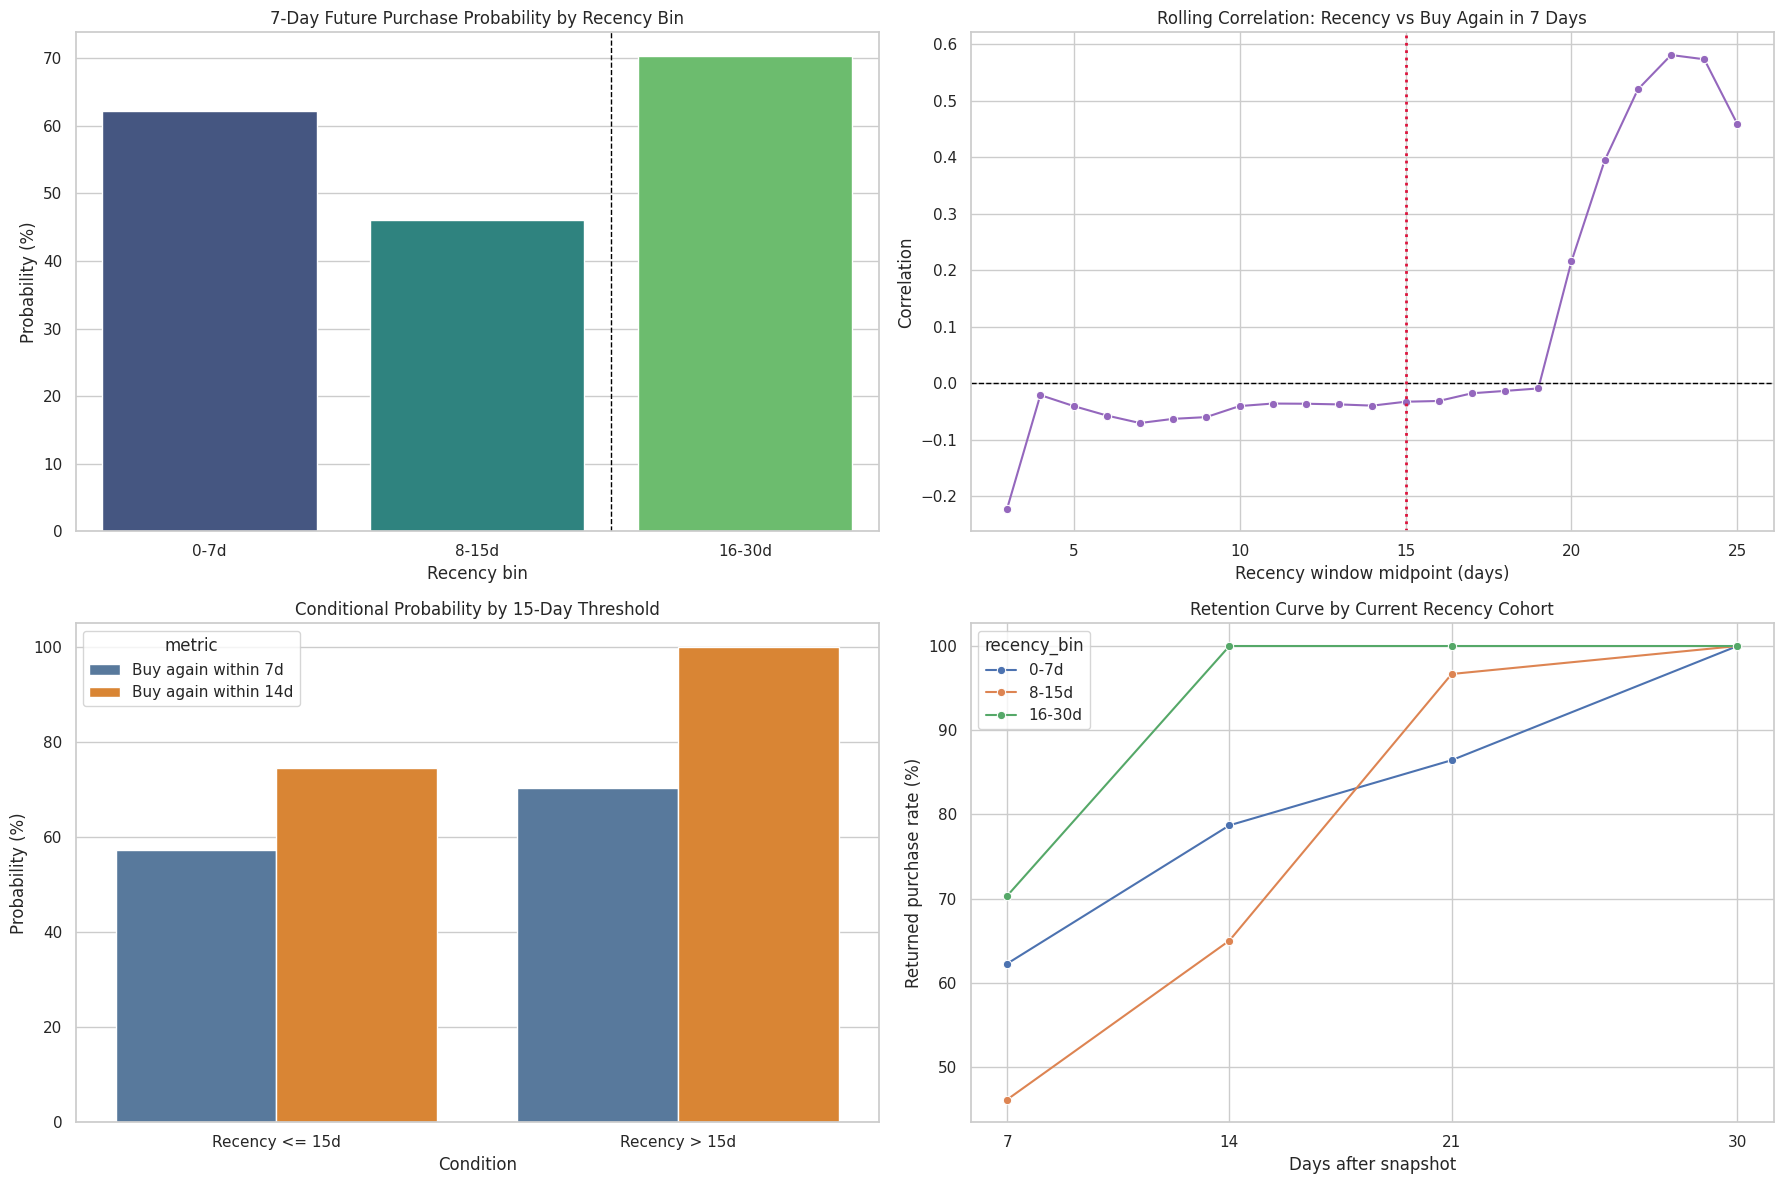

,recency_bin,observations,avg_recency_days,avg_days_until_next_order,p_buy_again_7d_pct,p_buy_again_14d_pct,corr_recency_vs_buy_7d
0,0-7d,565468,3.056778,8.154598,62.283454,78.706841,-0.215847
1,8-15d,253237,11.067913,9.893199,46.148470,65.025648,-0.043239
2,16-30d,247092,22.738025,5.235115,70.338578,100.000000,0.578977


,condition,observations,p_buy_again_7d_pct,p_buy_again_14d_pct,avg_days_until_next_order
0,Recency <= 15d,818705,57.292676,74.475055,8.692371
1,Recency > 15d,247092,70.338578,100.000000,5.235115


,recency_bin,return_rate_pct,days_after_snapshot
0,0-7d,62.283454,7
1,8-15d,46.148470,7
2,16-30d,70.338578,7
3,0-7d,78.706841,14
4,8-15d,65.025648,14
5,16-30d,100.000000,14
6,0-7d,86.444679,21
7,8-15d,96.678605,21
8,16-30d,100.000000,21
9,0-7d,100.000000,30


Recency threshold summary
- P(Buy again within 7 days | Recency <= 15) = 57.3%
- P(Buy again within 7 days | Recency > 15) = 70.3%
- Weakest short-term return band is 8-15d (46.1%).
- Strongest rolling negative relationship appears around 0-6d (corr = -0.22).
- In this dataset, 16-30d rebounds because many shoppers are entering their normal reorder cycle, so day 15 behaves more like an inflection point than a hard churn cliff.
- Use this together with segment, gap, and health-score views because Instacart inter-order gaps are capped near 30 days.


In [11]:
# --- Recency threshold diagnostics ---
RECENCY_ACTION_THRESHOLD = 15
EARLY_PURCHASE_WINDOW = 7
ALT_PURCHASE_WINDOW = 14
ROLLING_WINDOW_DAYS = 7
CURVE_HORIZONS = [7, 14, 21, 30]
recency_bin_order = ["0-7d", "8-15d", "16-30d"]


def safe_binary_corr(frame, value_col, binary_col):
    if frame.empty or frame[binary_col].nunique() < 2:
        return np.nan
    return frame[value_col].corr(frame[binary_col].astype(float))


# Rebuild prerequisites when this cell is run standalone.
if "df" not in globals():
    import instacart_quality.data_access as data_access_module

    fallback_root = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd().resolve()
    fallback_sample = USE_SAMPLE if "USE_SAMPLE" in globals() else False
    df = data_access_module.load_customer_behavior_data(
        use_sample=fallback_sample,
        project_root=fallback_root,
    )

if "order_value" not in globals():
    order_value = (
        df.groupby(["user_id", "order_id", "order_date", "order_dow"], observed=False)
        .agg(order_value=("total_price", "sum"))
        .reset_index()
    )
    order_value["order_month"] = order_value["order_date"].dt.to_period("M").dt.to_timestamp()

if "latest_order_date" not in globals() or "trend_monthly" not in globals():
    latest_order_date = df["order_date"].max()
    monthly_kpis = (
        order_value.groupby("order_month", observed=False)
        .agg(active_customers=("user_id", "nunique"))
        .reset_index()
        .sort_values("order_month")
    )
    latest_month = latest_order_date.to_period("M").to_timestamp()
    exclude_partial_month = (
        latest_month == monthly_kpis["order_month"].max()
        and latest_order_date.day <= 7
    )
    trend_monthly = (
        monthly_kpis[monthly_kpis["order_month"] < latest_month].copy()
        if exclude_partial_month
        else monthly_kpis.copy()
    )

if "customer_health_state" not in globals():
    analysis_months = trend_monthly["order_month"].drop_duplicates().sort_values()
    month_calendar = pd.DataFrame({"order_month": pd.Index(analysis_months)})
    month_calendar["month_label"] = month_calendar["order_month"].dt.strftime("%Y-%m")
    month_calendar["month_end"] = month_calendar["order_month"] + pd.offsets.MonthEnd(1)

    all_users = order_value[["user_id"]].drop_duplicates()
    user_month_grid = (
        all_users.assign(key=1)
        .merge(month_calendar.assign(key=1), on="key")
        .drop(columns="key")
        .sort_values(["month_end", "user_id"])
        .reset_index(drop=True)
    )
    user_order_history = (
        order_value[["user_id", "order_date"]]
        .drop_duplicates()
        .sort_values(["order_date", "user_id"])
        .reset_index(drop=True)
    )
    customer_health_state = pd.merge_asof(
        user_month_grid,
        user_order_history,
        by="user_id",
        left_on="month_end",
        right_on="order_date",
        direction="backward",
    ).rename(columns={"order_date": "last_order_date_to_month_end"})
    customer_health_state["days_since_last_order"] = (
        customer_health_state["month_end"] - customer_health_state["last_order_date_to_month_end"]
    ).dt.days

future_order_history = (
    order_value[["user_id", "order_date"]]
    .drop_duplicates()
    .sort_values(["order_date", "user_id"])
    .reset_index(drop=True)
)

recency_future_eval = pd.merge_asof(
    customer_health_state.sort_values(["month_end", "user_id"]).reset_index(drop=True),
    future_order_history,
    by="user_id",
    left_on="month_end",
    right_on="order_date",
    direction="forward",
).rename(columns={"order_date": "next_order_after_snapshot"})

recency_future_eval = recency_future_eval[
    recency_future_eval["last_order_date_to_month_end"].notna()
].copy()
recency_future_eval["lookahead_complete"] = (
    recency_future_eval["month_end"] + pd.Timedelta(days=max(CURVE_HORIZONS)) <= latest_order_date
)
recency_future_eval["days_until_next_order"] = (
    recency_future_eval["next_order_after_snapshot"] - recency_future_eval["month_end"]
).dt.days
recency_future_eval = recency_future_eval[
    recency_future_eval["lookahead_complete"]
    & recency_future_eval["days_since_last_order"].between(0, 30)
].copy()
recency_future_eval["buy_again_7d"] = (
    recency_future_eval["days_until_next_order"].le(EARLY_PURCHASE_WINDOW).fillna(False)
)
recency_future_eval["buy_again_14d"] = (
    recency_future_eval["days_until_next_order"].le(ALT_PURCHASE_WINDOW).fillna(False)
)
recency_future_eval["recency_bin"] = pd.cut(
    recency_future_eval["days_since_last_order"],
    bins=[-1, 7, 15, 30],
    labels=recency_bin_order,
)

recency_bin_summary = (
    recency_future_eval.groupby("recency_bin", observed=False)
    .agg(
        observations=("user_id", "size"),
        avg_recency_days=("days_since_last_order", "mean"),
        avg_days_until_next_order=("days_until_next_order", "mean"),
        p_buy_again_7d_pct=("buy_again_7d", lambda s: 100 * s.mean()),
        p_buy_again_14d_pct=("buy_again_14d", lambda s: 100 * s.mean()),
    )
    .reindex(recency_bin_order)
    .reset_index()
)
recency_bin_corr = (
    recency_future_eval.groupby("recency_bin", observed=False)
    .apply(
        lambda g: safe_binary_corr(g, "days_since_last_order", "buy_again_7d"),
        include_groups=False,
    )
    .reindex(recency_bin_order)
    .rename("corr_recency_vs_buy_7d")
    .reset_index()
)
recency_bin_summary = recency_bin_summary.merge(recency_bin_corr, on="recency_bin", how="left")

rolling_corr_rows = []
for start_day in range(0, 30 - ROLLING_WINDOW_DAYS + 2):
    end_day = start_day + ROLLING_WINDOW_DAYS - 1
    subset = recency_future_eval[
        recency_future_eval["days_since_last_order"].between(start_day, end_day)
    ]
    rolling_corr_rows.append(
        {
            "window_label": f"{start_day}-{end_day}d",
            "window_mid": (start_day + end_day) / 2,
            "observations": len(subset),
            "buy_again_7d_pct": 100 * subset["buy_again_7d"].mean() if len(subset) else np.nan,
            "corr_recency_vs_buy_7d": safe_binary_corr(subset, "days_since_last_order", "buy_again_7d"),
        }
    )
rolling_corr = pd.DataFrame(rolling_corr_rows)
rolling_corr_plot = rolling_corr.dropna(subset=["corr_recency_vs_buy_7d"]).copy()

conditional_probability = pd.DataFrame(
    {
        "condition": [f"Recency <= {RECENCY_ACTION_THRESHOLD}d", f"Recency > {RECENCY_ACTION_THRESHOLD}d"],
        "observations": [
            recency_future_eval[recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD].shape[0],
            recency_future_eval[recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD].shape[0],
        ],
        "p_buy_again_7d_pct": [
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD,
                "buy_again_7d",
            ].mean(),
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD,
                "buy_again_7d",
            ].mean(),
        ],
        "p_buy_again_14d_pct": [
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD,
                "buy_again_14d",
            ].mean(),
            100
            * recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD,
                "buy_again_14d",
            ].mean(),
        ],
        "avg_days_until_next_order": [
            recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] <= RECENCY_ACTION_THRESHOLD,
                "days_until_next_order",
            ].mean(),
            recency_future_eval.loc[
                recency_future_eval["days_since_last_order"] > RECENCY_ACTION_THRESHOLD,
                "days_until_next_order",
            ].mean(),
        ],
    }
)

conditional_probability_long = conditional_probability.melt(
    id_vars=["condition", "observations"],
    value_vars=["p_buy_again_7d_pct", "p_buy_again_14d_pct"],
    var_name="metric",
    value_name="probability_pct",
)
conditional_probability_long["metric"] = conditional_probability_long["metric"].map(
    {
        "p_buy_again_7d_pct": "Buy again within 7d",
        "p_buy_again_14d_pct": "Buy again within 14d",
    }
)

retention_curve_by_recency = []
for horizon in CURVE_HORIZONS:
    horizon_curve = (
        recency_future_eval.groupby("recency_bin", observed=False)["days_until_next_order"]
        .apply(lambda s: 100 * s.le(horizon).mean())
        .reindex(recency_bin_order)
        .rename("return_rate_pct")
        .reset_index()
    )
    horizon_curve["days_after_snapshot"] = horizon
    retention_curve_by_recency.append(horizon_curve)
retention_curve_by_recency = pd.concat(retention_curve_by_recency, ignore_index=True)
retention_curve_by_recency = retention_curve_by_recency.dropna(subset=["return_rate_pct"])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=recency_bin_summary,
    x="recency_bin",
    y="p_buy_again_7d_pct",
    hue="recency_bin",
    order=recency_bin_order,
    palette="viridis",
    dodge=False,
    ax=axes[0, 0],
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].axvline(1.5, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("7-Day Future Purchase Probability by Recency Bin")
axes[0, 0].set_xlabel("Recency bin")
axes[0, 0].set_ylabel("Probability (%)")

if rolling_corr_plot.empty:
    axes[0, 1].text(0.5, 0.5, "Not enough variation for rolling correlation", ha="center", va="center")
    axes[0, 1].set_axis_off()
else:
    sns.lineplot(
        data=rolling_corr_plot,
        x="window_mid",
        y="corr_recency_vs_buy_7d",
        marker="o",
        ax=axes[0, 1],
        color="tab:purple",
    )
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 1].axvline(RECENCY_ACTION_THRESHOLD, color="crimson", linestyle=":", linewidth=2)
    axes[0, 1].set_title("Rolling Correlation: Recency vs Buy Again in 7 Days")
    axes[0, 1].set_xlabel("Recency window midpoint (days)")
    axes[0, 1].set_ylabel("Correlation")

sns.barplot(
    data=conditional_probability_long,
    x="condition",
    y="probability_pct",
    hue="metric",
    palette=["#4C78A8", "#F58518"],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Conditional Probability by 15-Day Threshold")
axes[1, 0].set_xlabel("Condition")
axes[1, 0].set_ylabel("Probability (%)")

sns.lineplot(
    data=retention_curve_by_recency,
    x="days_after_snapshot",
    y="return_rate_pct",
    hue="recency_bin",
    hue_order=recency_bin_order,
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Retention Curve by Current Recency Cohort")
axes[1, 1].set_xlabel("Days after snapshot")
axes[1, 1].set_ylabel("Returned purchase rate (%)")
axes[1, 1].set_xticks(CURVE_HORIZONS)

plt.tight_layout()
plt.show()

display(
    recency_bin_summary,
    title="Recency bin summary:"
)
display(
    conditional_probability,
    title="Conditional probability check at 15 days:"
)
display(
    retention_curve_by_recency,
    title="Retention curve by recency cohort:"
)

le_15 = conditional_probability.loc[0, "p_buy_again_7d_pct"]
gt_15 = conditional_probability.loc[1, "p_buy_again_7d_pct"]
weakest_bin = recency_bin_summary.loc[
    recency_bin_summary["p_buy_again_7d_pct"].idxmin(),
    "recency_bin",
]
strongest_bin = recency_bin_summary.loc[
    recency_bin_summary["p_buy_again_7d_pct"].idxmax(),
    "recency_bin",
]
if rolling_corr_plot.empty:
    lowest_corr_label = "N/A"
    lowest_corr_value = np.nan
else:
    lowest_corr_window = rolling_corr_plot.loc[
        rolling_corr_plot["corr_recency_vs_buy_7d"].idxmin()
    ]
    lowest_corr_label = lowest_corr_window["window_label"]
    lowest_corr_value = lowest_corr_window["corr_recency_vs_buy_7d"]

print("Recency threshold summary")
print(
    f"- P(Buy again within 7 days | Recency <= {RECENCY_ACTION_THRESHOLD}) = {le_15:.1f}%"
)
print(
    f"- P(Buy again within 7 days | Recency > {RECENCY_ACTION_THRESHOLD}) = {gt_15:.1f}%"
)
print(
    f"- Weakest short-term return band is {weakest_bin} "
    f"({recency_bin_summary.loc[recency_bin_summary['recency_bin'] == weakest_bin, 'p_buy_again_7d_pct'].iloc[0]:.1f}%)."
)
if pd.notna(lowest_corr_value):
    print(
        f"- Strongest rolling negative relationship appears around {lowest_corr_label} "
        f"(corr = {lowest_corr_value:.2f})."
    )
else:
    print("- Rolling correlation is unavailable in some windows because the outcome has little variation.")
print(
    f"- In this dataset, {strongest_bin} rebounds because many shoppers are entering their normal reorder cycle, "
    "so day 15 behaves more like an inflection point than a hard churn cliff."
)
print(
    "- Use this together with segment, gap, and health-score views because Instacart inter-order gaps are capped near 30 days."
)

## Habit Formation
1. วิเคราะห์ Insight: ทำไมต้อง 15 วัน?

    ช่วง 0-15 วัน (The Honeymoon Phase): ลูกค้าใหม่มีความตื่นเต้น (Novelty Effect) และกำลังทดลองใช้บริการ ช่วงนี้ Reorder Ratio มักจะสูงเพราะเขายังมี Intent ที่ชัดเจน

    จุด 15 วัน (The Chasm): หลังจากผ่านไป 2 สัปดาห์ ความตื่นเต้นเริ่มลดลง (Friction เริ่มชนะ Novelty) หากเราไม่สามารถทำให้การซื้อกลายเป็น "นิสัย" (Habit) ได้ในช่วงนี้ เขาจะหายไปเลย

    ถ้าเกิน 15 วันแล้วยังอยู่ (The Retained Zone): ถ้าลูกค้ายังมีการเคลื่อนไหวหรือเราดึงเขากลับมาได้หลัง 15 วัน มักแปลว่าเขาเริ่ม "ติด" (Sticky) หรือเห็น Value จริงๆ ของบริการเราแล้ว โอกาสเป็นลูกค้าประจำ (Loyal Customer) จะสูงขึ้นมาก

## สิ่งแนะนําที่ควรทํา 

2. การคาดการณ์ (Predictive Power)

ในทางกราฟหรือสถิติ เราสามารถพิสูจน์และใช้ประโยชน์จากเรื่องนี้ได้ผ่าน 2 เทคนิคครับ:

- Hazard Function: เป็นการวัด "โอกาสที่จะเลิก (Churn)" ณ เวลาใดเวลาหนึ่ง ถ้ากราฟ Hazard พุ่งสูงสุดที่ 15 วัน แล้วเริ่มลดลงหลังจากนั้น นั่นยืนยันสมมติฐานคุณว่า "ถ้าผ่าน 15 วันไปได้ ความเสี่ยงที่จะเลิกจะลดลง"

- Uplift Modeling: คุณสามารถทดลอง (A/B Test) ส่ง Notification หรือคูปองพิเศษในวันที่ 12-14 เพื่อ "ประคอง" ไม่ให้เขาร่วงหล่นในช่วงหน้าผา 15 วัน แล้วดูว่ากลุ่มที่ได้รับแรงกระตุ้นนี้มี LTV (Lifetime Value) สูงกว่ากลุ่มปกติหรือไม่

### 10) Conversion to Habit Rate by Order Depth

พลอตนี้ดูว่าเมื่อ `Recency` เปลี่ยนไป โอกาสที่ลูกค้าจะซื้อครั้งถัดไปภายใน `30 วัน` เปลี่ยนอย่างไร โดยแยกตามจำนวนออเดอร์สะสม

การแก้เวอร์ชันนี้ทำ 3 อย่างตรงตามข้อกังวล:
1. ใช้ **full order history** จาก `orders_with_dates` เพื่อให้เห็น cohort `1 order`, `2 orders`, และ `5+ orders` จริง
2. ปล่อยแกน Y แบบปกติ ไม่บีบไว้ที่ `95-101`
3. แยกกราฟ `30-day reference` ออกจาก `7-day practical proxy` เพราะใน Instacart ค่า inter-order gap ถูก **capped ที่ 30 วัน** ทำให้เส้น 30 วันมีแนวโน้มแบนเกือบทั้งหมดโดยโครงสร้างข้อมูลเอง

> สรุป: กราฟ 30 วันมีไว้เป็น **reference only** ส่วนกราฟ 7 วันคือกราฟที่ใช้ตีความเชิงธุรกิจได้จริง

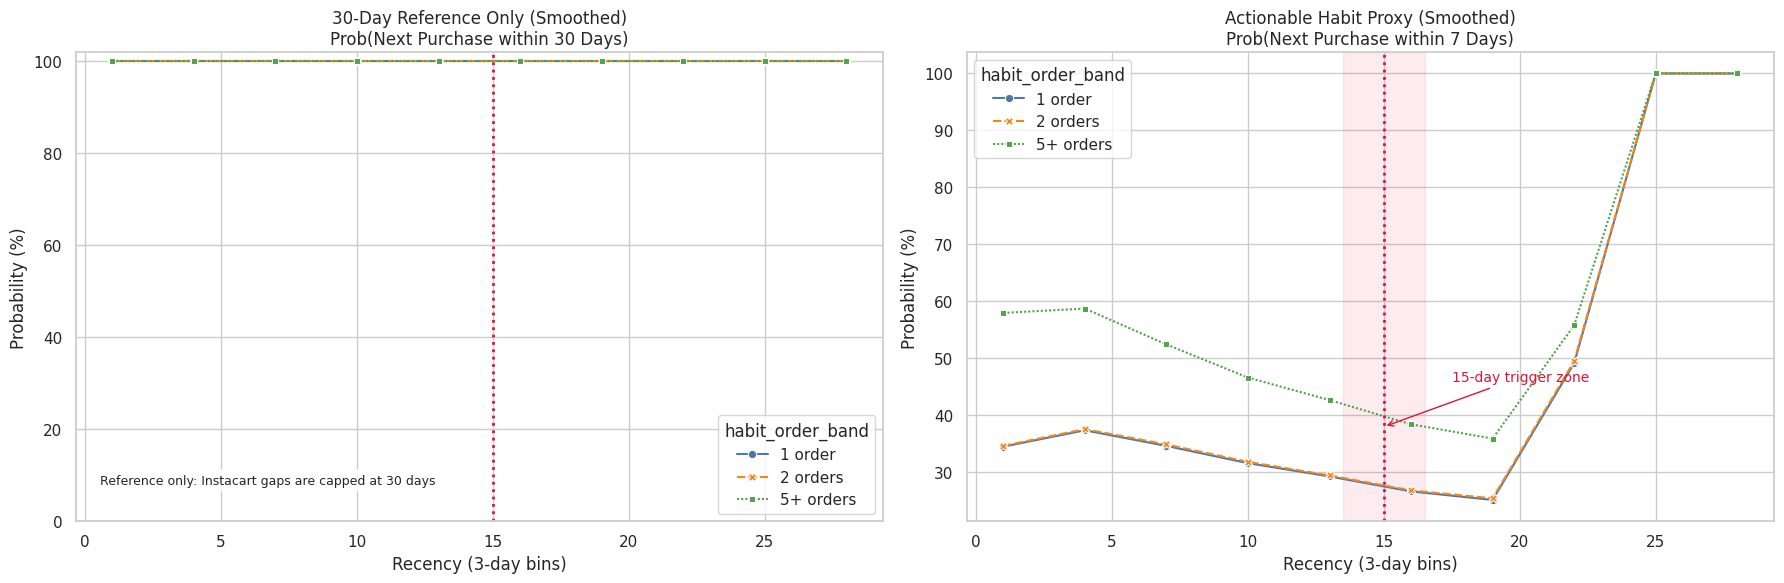

,habit_order_band,customers,order_transitions,avg_gap_to_next_order
0,1 order,203310,203310,15.560892
1,2 orders,203294,203294,15.506213
2,5+ orders,162400,2357681,9.981970


,habit_order_band,recency_bin_label,observations,prob_next_purchase_30d_pct,prob_next_purchase_7d_pct
0,1 order,0-2d,594083,100.0,34.532583
1,1 order,3-5d,528576,100.0,37.399530
2,1 order,6-8d,423474,100.0,34.659180
3,1 order,9-11d,347393,100.0,31.630283
4,1 order,12-14d,295226,100.0,29.306302
5,1 order,15-17d,247398,100.0,26.680042
6,1 order,18-20d,219089,100.0,25.184324
7,1 order,21-23d,188452,100.0,49.182528
8,1 order,24-26d,169777,100.0,100.000000
9,1 order,27-29d,150217,100.0,100.000000


,habit_order_band,trigger_prob_7d_pct
0,1 order,26.680042
1,2 orders,26.847693
2,5+ orders,38.456159


Conversion to habit-rate summary
- Fixed the cohort issue by using full order history; min observed order_number = 1, so 1-order and 2-order cohorts are now included.
- The curve is now smoothed into 3-day bins and filtered to observations > 20 to remove noisy tail spikes.
- The 30-day chart remains a reference plot only because Instacart inter-order gaps are capped at 30 days.
- Around the 15-day trigger zone, 7-day repeat probability is about 26.7% for 1 order, 26.8% for 2 orders, and 38.5% for 5+ orders.
- Business summary: day 15 is the practical intervention point; after that, short-term repeat intent is materially softer, especially for low-order cohorts.


In [8]:
HABIT_WINDOW_DAYS = 30
HABIT_EARLY_WINDOW = 7
HABIT_BIN_DAYS = 3
MIN_OBSERVATIONS_TO_PLOT = 50
TRIGGER_DAY = 15
habit_band_order = ["1 order", "2 orders", "5+ orders"]
habit_palette = {
    "1 order": "#4C78A8",
    "2 orders": "#F58518",
    "5+ orders": "#54A24B",
}


# 3. ลองลด MIN_OBSERVATIONS ดูถ้าข้อมูลหาย
MIN_OBSERVATIONS_TO_PLOT = 20 # ลดลงเล็กน้อยเพื่อให้เห็นปลายกราฟ

# === POLARS CONVERSION: Extract unique orders with next_order_date using window function ===
orders_all_pl = (
    df.select([
        pl.col("user_id"),
        pl.col("order_id"),
        pl.col("order_date"),
        pl.col("order_number"),
    ])
    .unique()
    .sort(["user_id", "order_number"])
    .with_columns([
        pl.col("order_date").shift(-1).over("user_id").alias("next_order_date"),
    ])
)

# Compute days_to_next_order in Polars, convert to pandas for downstream analysis
orders_all_pl = orders_all_pl.with_columns([
    (pl.col("next_order_date") - pl.col("order_date")).dt.total_days().alias("days_to_next_order")
])

# Convert to pandas for the complex multi-dimensional groupby operations
orders_all = orders_all_pl.to_pandas()

# 1. ต้องคำนวณ Gap Days ก่อน (สำคัญมาก!)
# (Already calculated in Polars window function above)

# 2. ทำความสะอาดข้อมูล
habit_event_base = orders_all.dropna(subset=["days_to_next_order"]).copy()

habit_event_base = orders_all.dropna(subset=["days_to_next_order"]).copy()
habit_event_base = habit_event_base[habit_event_base["days_to_next_order"].between(1, 30)].copy()
habit_event_base["habit_order_band"] = np.select(
    [
        habit_event_base["order_number"].eq(1),
        habit_event_base["order_number"].eq(2),
        habit_event_base["order_number"].ge(5),
    ],
    habit_band_order,
    default="3-4 orders",
)
habit_event_base = habit_event_base[
    habit_event_base["habit_order_band"].isin(habit_band_order)
].copy()

habit_curve_rows = []
for recency_day in range(0, HABIT_WINDOW_DAYS):
    eligible = habit_event_base[habit_event_base["days_to_next_order"] > recency_day]
    for band in habit_band_order:
        subset = eligible[eligible["habit_order_band"] == band]
        if subset.empty:
            continue
        habit_curve_rows.append(
            {
                "recency": recency_day,
                "habit_order_band": band,
                "observations": len(subset),
                "prob_next_purchase_30d_pct": 100 * (subset["days_to_next_order"] <= recency_day + HABIT_WINDOW_DAYS).mean(),
                "prob_next_purchase_7d_pct": 100 * (subset["days_to_next_order"] <= recency_day + HABIT_EARLY_WINDOW).mean(),
            }
        )
habit_rate_curve = pd.DataFrame(habit_curve_rows)
habit_rate_curve = habit_rate_curve[habit_rate_curve["observations"] > MIN_OBSERVATIONS_TO_PLOT].copy()

habit_rate_curve["recency_bin_start"] = (
    habit_rate_curve["recency"] // HABIT_BIN_DAYS
) * HABIT_BIN_DAYS
habit_rate_curve["recency_bin_label"] = habit_rate_curve.apply(
    lambda row: f"{int(row['recency_bin_start'])}-{int(min(row['recency_bin_start'] + HABIT_BIN_DAYS - 1, HABIT_WINDOW_DAYS - 1))}d",
    axis=1,
)
habit_rate_curve["recency_mid"] = habit_rate_curve["recency_bin_start"] + (HABIT_BIN_DAYS - 1) / 2

habit_rate_curve_binned = (
    habit_rate_curve.groupby(["habit_order_band", "recency_bin_start", "recency_bin_label", "recency_mid"], observed=False)
    .agg(
        observations=("observations", "sum"),
        prob_next_purchase_30d_pct=("prob_next_purchase_30d_pct", "mean"),
        prob_next_purchase_7d_pct=("prob_next_purchase_7d_pct", "mean"),
    )
    .reset_index()
    .sort_values(["habit_order_band", "recency_bin_start"])
)

habit_rate_summary = (
    habit_event_base.groupby("habit_order_band", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        order_transitions=("order_id", "count"),
        avg_gap_to_next_order=("days_to_next_order", "mean"),
    )
    .reindex(habit_band_order)
    .reset_index()
)

trigger_bin = habit_rate_curve_binned[
    habit_rate_curve_binned["recency_bin_start"].between(TRIGGER_DAY - (HABIT_BIN_DAYS - 1), TRIGGER_DAY)
].copy()
trigger_snapshot = (
    trigger_bin.groupby("habit_order_band", observed=False)
    .agg(trigger_prob_7d_pct=("prob_next_purchase_7d_pct", "mean"))
    .reindex(habit_band_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=habit_rate_curve_binned,
    x="recency_mid",
    y="prob_next_purchase_30d_pct",
    hue="habit_order_band",
    hue_order=habit_band_order,
    style="habit_order_band",
    style_order=habit_band_order,
    markers=True,
    dashes=True,
    palette=habit_palette,
    ax=axes[0],
)
axes[0].axvline(TRIGGER_DAY, color="crimson", linestyle=":", linewidth=2)
axes[0].set_title("30-Day Reference Only (Smoothed)\nProb(Next Purchase within 30 Days)")
axes[0].set_xlabel("Recency (3-day bins)")
axes[0].set_ylabel("Probability (%)")
axes[0].set_ylim(0, 102)
axes[0].text(
    0.03,
    0.08,
    "Reference only: Instacart gaps are capped at 30 days",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
)

sns.lineplot(
    data=habit_rate_curve_binned,
    x="recency_mid",
    y="prob_next_purchase_7d_pct",
    hue="habit_order_band",
    hue_order=habit_band_order,
    style="habit_order_band",
    style_order=habit_band_order,
    markers=True,
    dashes=True,
    palette=habit_palette,
    ax=axes[1],
)
axes[1].axvline(TRIGGER_DAY, color="crimson", linestyle=":", linewidth=2, label="15-day trigger")
axes[1].axvspan(TRIGGER_DAY - 1.5, TRIGGER_DAY + 1.5, color="crimson", alpha=0.08)
axes[1].set_title("Actionable Habit Proxy (Smoothed)\nProb(Next Purchase within 7 Days)")
axes[1].set_xlabel("Recency (3-day bins)")
axes[1].set_ylabel("Probability (%)")
axes[1].annotate(
    "15-day trigger zone",
    xy=(TRIGGER_DAY, habit_rate_curve_binned["prob_next_purchase_7d_pct"].median()),
    xytext=(TRIGGER_DAY + 2.5, habit_rate_curve_binned["prob_next_purchase_7d_pct"].median() + 8),
    arrowprops={"arrowstyle": "->", "color": "crimson"},
    color="crimson",
    fontsize=10,
)

plt.tight_layout()
plt.show()

display(habit_rate_summary, title="Habit-rate summary by order depth:")
display(
    habit_rate_curve_binned[[
        "habit_order_band",
        "recency_bin_label",
        "observations",
        "prob_next_purchase_30d_pct",
        "prob_next_purchase_7d_pct",
    ]],
    title="Smoothed habit-rate curve (3-day bins, observations > 50):",
    n=30,
)
display(trigger_snapshot, title="15-day trigger snapshot by order depth:", n=10)

min_order_number = int(orders_all["order_number"].min())
trigger_1 = trigger_snapshot.loc[trigger_snapshot["habit_order_band"] == "1 order", "trigger_prob_7d_pct"].iloc[0]
trigger_2 = trigger_snapshot.loc[trigger_snapshot["habit_order_band"] == "2 orders", "trigger_prob_7d_pct"].iloc[0]
trigger_5 = trigger_snapshot.loc[trigger_snapshot["habit_order_band"] == "5+ orders", "trigger_prob_7d_pct"].iloc[0]

print("Conversion to habit-rate summary")
print(
    f"- Fixed the cohort issue by using full order history; min observed order_number = {min_order_number}, so 1-order and 2-order cohorts are now included."
)
print(
    f"- The curve is now smoothed into {HABIT_BIN_DAYS}-day bins and filtered to observations > {MIN_OBSERVATIONS_TO_PLOT} to remove noisy tail spikes."
)
print(
    "- The 30-day chart remains a reference plot only because Instacart inter-order gaps are capped at 30 days."
)
print(
    f"- Around the 15-day trigger zone, 7-day repeat probability is about {trigger_1:.1f}% for 1 order, {trigger_2:.1f}% for 2 orders, and {trigger_5:.1f}% for 5+ orders."
)
print(
    "- Business summary: day 15 is the practical intervention point; after that, short-term repeat intent is materially softer, especially for low-order cohorts."
)

## สรุป Insight เพิ่ม
Habit Gap: กลุ่ม 5+ orders (เส้นเขียว) มีความน่าจะเป็นสูงกว่ากลุ่ม 1-2 orders เกือบ 2 เท่า ในช่วงแรก นั่นคือ "ความแข็งแกร่งของ Habit"

The 15-Day Cliff: สังเกตเส้นสีเขียวครับ มันดิ่งลงชันมากจาก 60% เหลือ 40% เมื่อถึงวันที่ 15

    Insight: ต่อให้เป็นลูกค้าประจำ (5+ orders) ถ้าปล่อยให้หายไปถึง 15 วัน ความ "เหนียว" ของเขาจะหายไปจนเกือบเท่าลูกค้าใหม่

15-day Trigger Zone: นี่คือจุดที่คุณทำถูกมาก การมาร์กสีชมพูไว้บอกว่า "นี่คือวินาทีสุดท้ายที่จะดึง Habit กลับมาได้"